# Exploratory Analysis, Feature Selection, and Model Evaluation

This notebook analyzes the extracted multimodal features, constructs candidate feature sets, and evaluates classical machine-learning models for REST-vs-STRESS classification. The **primary evaluation is participant-wise nested cross-validation**, where feature selection and threshold tuning are performed using training participants only.

## 1. Setup

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, balanced_accuracy_score, f1_score, recall_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load the Extracted Feature Dataset

In [20]:
DATA_DIR = Path("/content/drive/MyDrive/data")

In [3]:
features_path = Path(
    "/content/drive/MyDrive/data/stress_features_30s_multimodal_cleaned.csv"
)

df = pd.read_csv(features_path)

print("Shape:", df.shape)
display(df.head())

Shape: (4540, 157)


,recording_id,participant_id,block_id,stage_label,label,start_sec,end_sec,window_sec,BVP_Clean_Mean,BVP_Clean_Median,...,EDA_Raw_Mean_DeltaBaseline,EDA_Tonic_Mean_DeltaBaseline,EDA_Phasic_Mean_DeltaBaseline,SCR_Peaks_N_DeltaBaseline,SCR_Amplitude_Mean_DeltaBaseline,PPG_Rate_Mean_DeltaBaseline,PPI_Mean_DeltaBaseline,HRV_RMSSD_DeltaBaseline,HRV_SDNN_DeltaBaseline,ACC_Mag_Mean_DeltaBaseline
0,S01,S01,1,baseline_rest,REST,371.0,401.0,30,-0.031439,3.676886,...,-0.039180,-0.038771,-0.000162,8.0,-0.002414,1.044078,-0.006007,-40.023118,-76.694847,0.011893
1,S01,S01,1,baseline_rest,REST,386.0,416.0,30,0.253803,4.955127,...,-0.031460,-0.032067,0.000605,7.0,-0.002177,2.919855,-0.046908,-137.841593,-101.951098,0.014482
2,S01,S01,1,baseline_rest,REST,401.0,431.0,30,0.544310,3.131829,...,-0.020600,-0.019618,-0.001046,9.0,-0.002290,4.061531,-0.069623,-214.289657,-129.931664,0.015265
3,S01,S01,1,baseline_rest,REST,416.0,446.0,30,-0.237565,2.244995,...,0.003766,0.003907,-0.000089,-6.0,-0.001264,-4.899191,0.032047,-309.677131,-211.497203,0.015480
4,S01,S01,1,baseline_rest,REST,431.0,461.0,30,0.404348,1.102333,...,0.011091,0.011469,-0.000493,7.0,-0.003294,11.915276,-0.080226,-306.886828,-165.455071,0.010090


## 3. Dataset Overview

In [4]:
print("Dataset shape:", df.shape)

print("\nLabel counts:")
print(df["label"].value_counts())

print("\nLabel percentages:")
print((df["label"].value_counts(normalize=True) * 100).round(2))

print("\nNumber of participants:")
print(df["participant_id"].nunique())

print("\nNumber of recordings:")
print(df["recording_id"].nunique())

print("\nStage labels:")
print(df["stage_label"].value_counts())

Dataset shape: (4540, 157)

Label counts:
label
REST      3902
STRESS     638
Name: count, dtype: int64

Label percentages:
label
REST      85.95
STRESS    14.05
Name: proportion, dtype: float64

Number of participants:
35

Number of recordings:
36

Stage labels:
stage_label
post_tmct_rest                1286
baseline_rest                 1275
post_opposite_opinion_rest     863
tmct                           431
post_stroop_rest               354
stroop                         104
pre_task_rest                  100
subtraction                     38
opposite_opinion                33
real_opinion                    32
post_real_opinion_rest          24
Name: count, dtype: int64


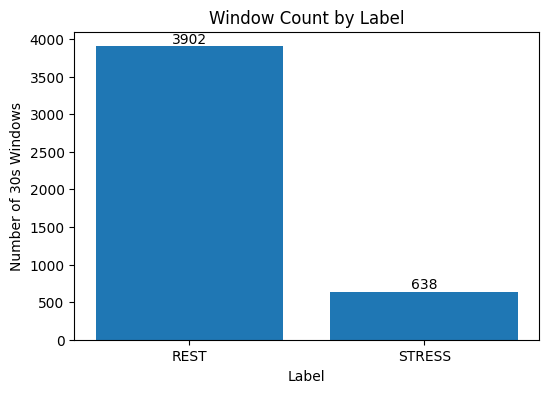

In [5]:
label_counts = df["label"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values)
plt.title("Window Count by Label")
plt.xlabel("Label")
plt.ylabel("Number of 30s Windows")

for i, v in enumerate(label_counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom")

plt.show()

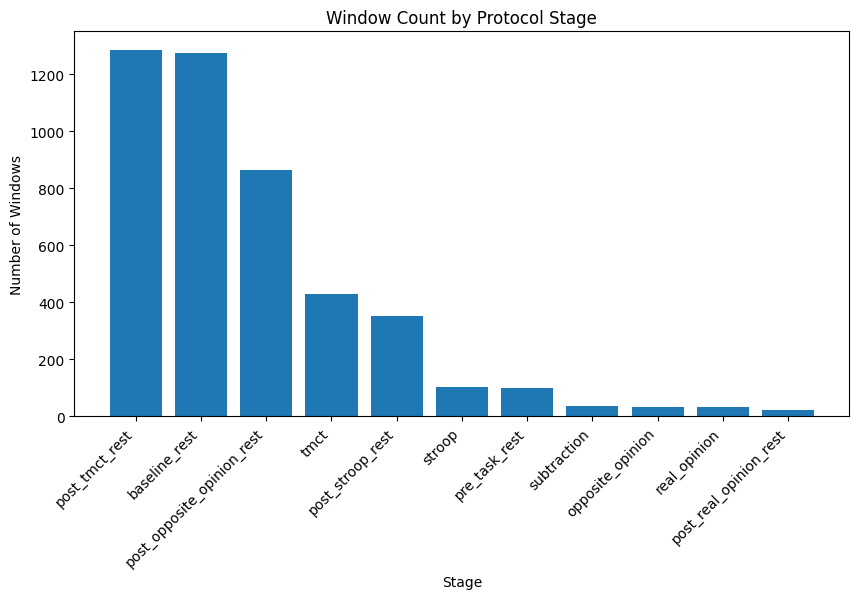

In [6]:
stage_counts = df["stage_label"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(stage_counts.index, stage_counts.values)
plt.title("Window Count by Protocol Stage")
plt.xlabel("Stage")
plt.ylabel("Number of Windows")
plt.xticks(rotation=45, ha="right")
plt.show()

## 4. Feature Matrix Preparation

Metadata and stored baseline-reference columns are separated from the numeric model features. Participant ID is retained only as the grouping variable for participant-wise validation.

In [7]:
metadata_cols = [
    "recording_id",
    "participant_id",
    "block_id",
    "stage_label",
    "label",
    "start_sec",
    "end_sec",
    "window_sec",
    "is_baseline_for_norm"
]

metadata_cols = [col for col in metadata_cols if col in df.columns]

baseline_mean_cols = [
    col for col in df.columns
    if col.endswith("_Baseline")
]

feature_cols = [
    col for col in df.columns
    if col not in metadata_cols
    and col not in baseline_mean_cols
]

# Keep only numeric features
feature_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print("Number of feature columns:", len(feature_cols))
print("Number of metadata columns:", len(metadata_cols))
print("Dropped raw baseline columns:", baseline_mean_cols)

Number of feature columns: 137
Number of metadata columns: 9
Dropped raw baseline columns: ['TEMP_Mean_Baseline', 'EDA_Raw_Mean_Baseline', 'EDA_Tonic_Mean_Baseline', 'EDA_Phasic_Mean_Baseline', 'SCR_Peaks_N_Baseline', 'SCR_Amplitude_Mean_Baseline', 'PPG_Rate_Mean_Baseline', 'PPI_Mean_Baseline', 'HRV_RMSSD_Baseline', 'HRV_SDNN_Baseline', 'ACC_Mag_Mean_Baseline']


In [8]:
X = df[feature_cols]
y = df["label"].map({"REST": 0, "STRESS": 1})
groups = df["participant_id"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of groups:", groups.nunique())

X shape: (4540, 137)
y shape: (4540,)
Number of groups: 35


In [9]:
missing_report = (
    X.isnull()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

missing_report.columns = ["feature", "missing_fraction"]

display(missing_report.head(30))

,feature,missing_fraction
0,HRV_HF,0.00022
1,BVP_Clean_Median,0.00000
2,BVP_Clean_SD,0.00000
3,BVP_Clean_Min,0.00000
4,BVP_Clean_Max,0.00000
5,BVP_Clean_Range,0.00000
6,BVP_Clean_Skew,0.00000
7,BVP_Clean_Kurtosis,0.00000
8,BVP_Clean_Mean,0.00000
9,BVP_Deriv1_Mean,0.00000


In [10]:
def get_feature_group(feature_name):
    if feature_name.startswith(("BVP", "PPG", "PPI", "HRV")):
        return "PPG_HRV"
    elif feature_name.startswith(("EDA", "SCR")):
        return "EDA"
    elif feature_name.startswith("ACC"):
        return "ACC"
    elif feature_name.startswith("TEMP"):
        return "TEMP"
    else:
        return "Other"


feature_groups = pd.DataFrame({
    "feature": feature_cols,
    "group": [get_feature_group(col) for col in feature_cols]
})

display(feature_groups["group"].value_counts())
display(feature_groups)

,count
group,
ACC,44
EDA,41
PPG_HRV,40
TEMP,12


,feature,group
0,BVP_Clean_Mean,PPG_HRV
1,BVP_Clean_Median,PPG_HRV
2,BVP_Clean_SD,PPG_HRV
3,BVP_Clean_Min,PPG_HRV
4,BVP_Clean_Max,PPG_HRV
...,...,...
132,PPG_Rate_Mean_DeltaBaseline,PPG_HRV
133,PPI_Mean_DeltaBaseline,PPG_HRV
134,HRV_RMSSD_DeltaBaseline,PPG_HRV
135,HRV_SDNN_DeltaBaseline,PPG_HRV


## 5. Exploratory Feature Analysis

### 5.1 Correlation analysis

Absolute Spearman correlations are used to identify strongly redundant feature pairs.

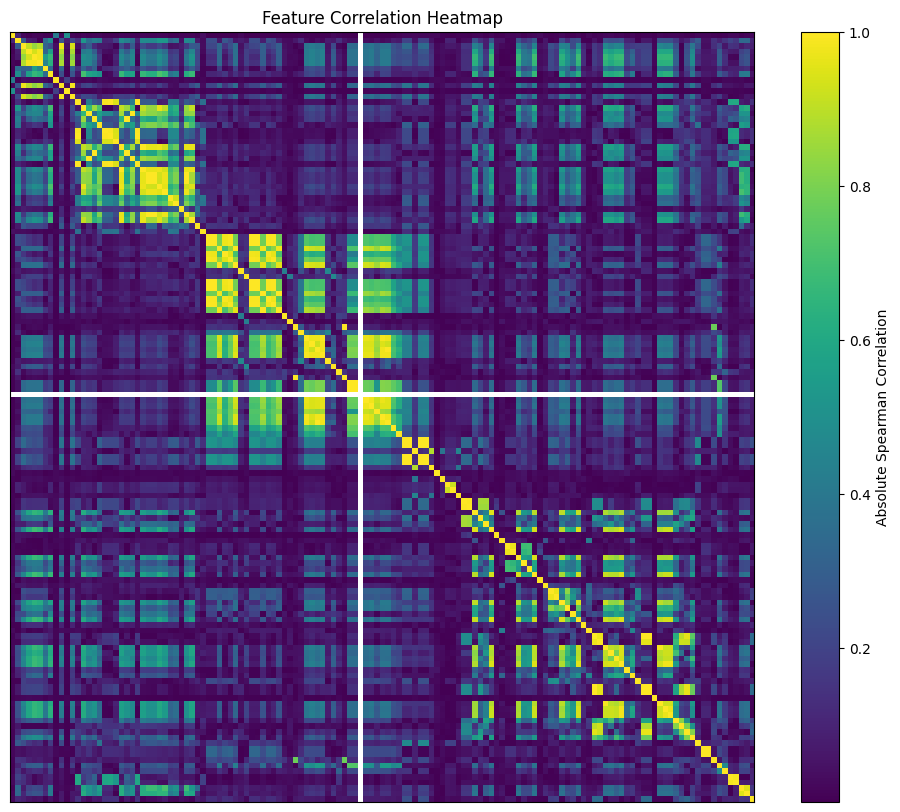

In [11]:
X_imputed = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X),
    columns=X.columns
)

corr = X_imputed.corr(method="spearman").abs()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Absolute Spearman Correlation")
plt.title("Feature Correlation Heatmap")
plt.xticks([])
plt.yticks([])
plt.show()

In [12]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "abs_corr"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_corr"] >= 0.95]
high_corr_pairs = high_corr_pairs.sort_values("abs_corr", ascending=False)

display(high_corr_pairs.head(50))
print("Number of highly correlated pairs:", len(high_corr_pairs))

,feature_1,feature_2,abs_corr
2281,PPI_Mean,HRV_MeanNN,1.000000
8970,ACC_RMS,ACC_Energy,1.000000
6479,SCR_Peaks_N,SCR_Peaks_Per_Min,1.000000
3190,HRV_SDSD,HRV_SD1,1.000000
2513,PPI_SD,HRV_SDNN,0.999993
1806,PPG_Rate_Min,PPI_Max,0.999991
6031,EDA_Phasic_Max,SCR_Height_Max,0.999991
3075,HRV_RMSSD,HRV_SDSD,0.999990
3081,HRV_RMSSD,HRV_SD1,0.999990
1925,PPG_Rate_Max,PPI_Min,0.999972


Number of highly correlated pairs: 119


### 5.2 REST vs. STRESS descriptive comparison

For each feature, the notebook summarizes REST and STRESS values, computes a standardized effect size, and reports a Mann–Whitney U test. These comparisons are **descriptive/exploratory** and are not used as standalone evidence of model generalization.

In [13]:
def compute_effect_size(rest_values, stress_values):
    """
    Cohen's d-like standardized mean difference.
    Positive value means higher in STRESS.
    """
    rest_values = np.asarray(rest_values, dtype=float)
    stress_values = np.asarray(stress_values, dtype=float)

    rest_values = rest_values[~np.isnan(rest_values)]
    stress_values = stress_values[~np.isnan(stress_values)]

    if len(rest_values) < 2 or len(stress_values) < 2:
        return np.nan

    pooled_sd = np.sqrt(
        ((len(rest_values) - 1) * np.var(rest_values, ddof=1) +
         (len(stress_values) - 1) * np.var(stress_values, ddof=1)) /
        (len(rest_values) + len(stress_values) - 2)
    )

    if pooled_sd == 0:
        return 0.0

    return (np.mean(stress_values) - np.mean(rest_values)) / pooled_sd

In [14]:
comparison_rows = []

for col in feature_cols:
    rest_values = df.loc[df["label"] == "REST", col].dropna()
    stress_values = df.loc[df["label"] == "STRESS", col].dropna()

    if len(rest_values) < 5 or len(stress_values) < 5:
        continue

    try:
        stat, p_value = mannwhitneyu(
            rest_values,
            stress_values,
            alternative="two-sided"
        )
    except Exception:
        p_value = np.nan

    effect = compute_effect_size(rest_values, stress_values)

    comparison_rows.append({
        "feature": col,
        "group": get_feature_group(col),
        "rest_mean": rest_values.mean(),
        "stress_mean": stress_values.mean(),
        "stress_minus_rest": stress_values.mean() - rest_values.mean(),
        "effect_size": effect,
        "abs_effect_size": abs(effect),
        "p_value": p_value,
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values("abs_effect_size", ascending=False)

display(comparison_df.head(40))

,feature,group,rest_mean,stress_mean,stress_minus_rest,effect_size,abs_effect_size,p_value
132,PPG_Rate_Mean_DeltaBaseline,PPG_HRV,-1.597942,4.620734,6.218675,0.919847,0.919847,6.619321e-65
133,PPI_Mean_DeltaBaseline,PPG_HRV,0.015289,-0.042049,-0.057337,-0.753477,0.753477,1.138303e-57
12,PPG_Rate_Mean,PPG_HRV,77.114065,82.650707,5.536642,0.578705,0.578705,2.154899e-31
130,SCR_Peaks_N_DeltaBaseline,EDA,1.433628,-4.480234,-5.913862,-0.576385,0.576385,6.495699e-35
17,PPG_Peaks_N,PPG_HRV,37.694259,40.431034,2.736775,0.570819,0.570819,2.289148e-30
19,PPI_Median,PPG_HRV,0.788758,0.730163,-0.058596,-0.540283,0.540283,6.697721e-37
23,HRV_MeanNN,PPG_HRV,797.602229,748.244968,-49.357261,-0.475787,0.475787,2.732751e-29
18,PPI_Mean,PPG_HRV,0.797602,0.748245,-0.049357,-0.475787,0.475787,2.732751e-29
1,BVP_Clean_Median,PPG_HRV,6.341736,4.243297,-2.098439,-0.438945,0.438945,2.505134e-24
67,SCR_Amplitude_Sum,EDA,0.487685,0.923551,0.435866,0.424391,0.424391,1.192096e-26


In [21]:
comparison_df.to_csv(DATA_DIR / "features_rest_vs_stress_comparison.csv", index=False)

/tmp/ipykernel_1876/1929022168.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rest_values, stress_values], labels=["REST", "STRESS"])


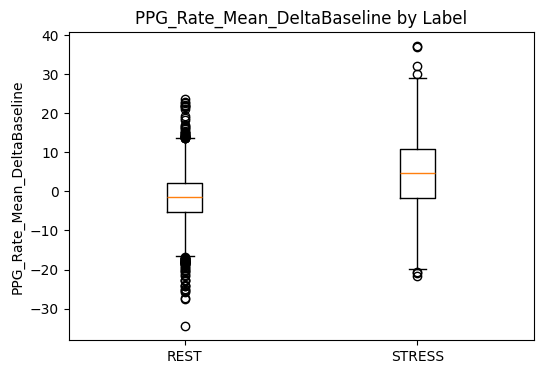

/tmp/ipykernel_1876/1929022168.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rest_values, stress_values], labels=["REST", "STRESS"])


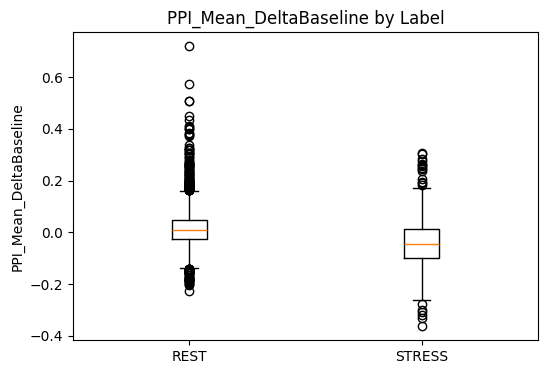

/tmp/ipykernel_1876/1929022168.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rest_values, stress_values], labels=["REST", "STRESS"])


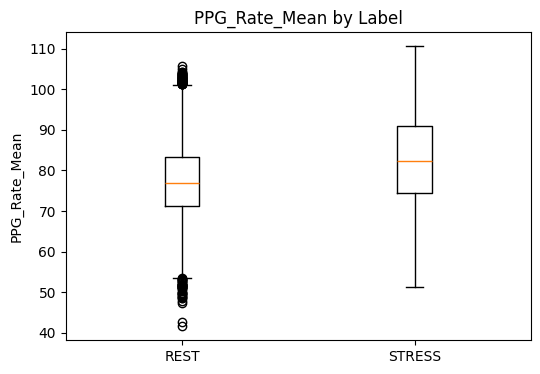

/tmp/ipykernel_1876/1929022168.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rest_values, stress_values], labels=["REST", "STRESS"])


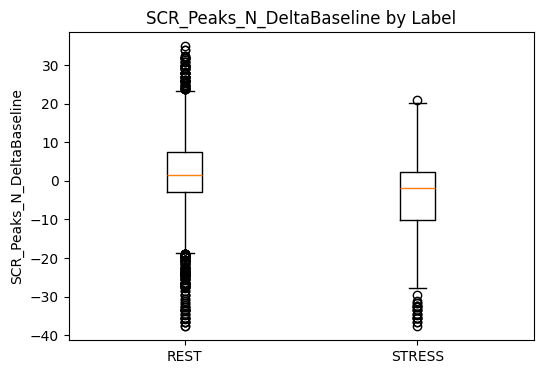

/tmp/ipykernel_1876/1929022168.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rest_values, stress_values], labels=["REST", "STRESS"])


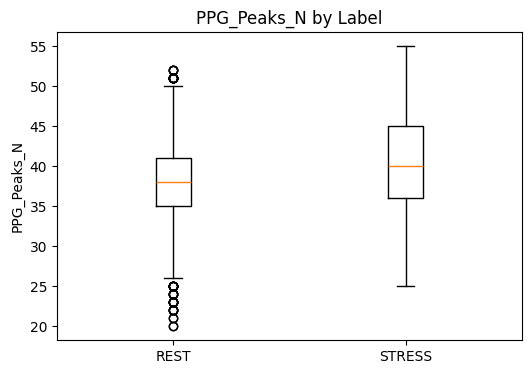

/tmp/ipykernel_1876/1929022168.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rest_values, stress_values], labels=["REST", "STRESS"])


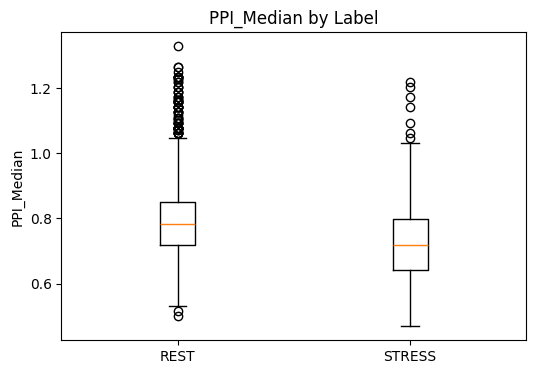

/tmp/ipykernel_1876/1929022168.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rest_values, stress_values], labels=["REST", "STRESS"])


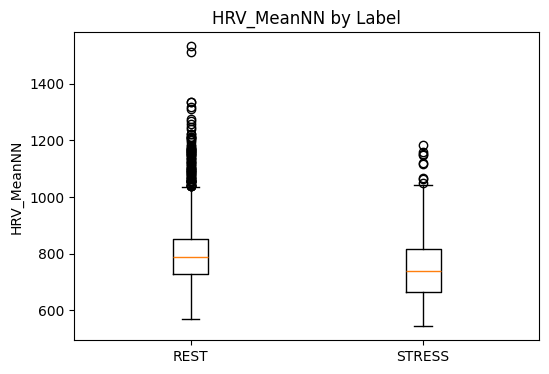

/tmp/ipykernel_1876/1929022168.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rest_values, stress_values], labels=["REST", "STRESS"])


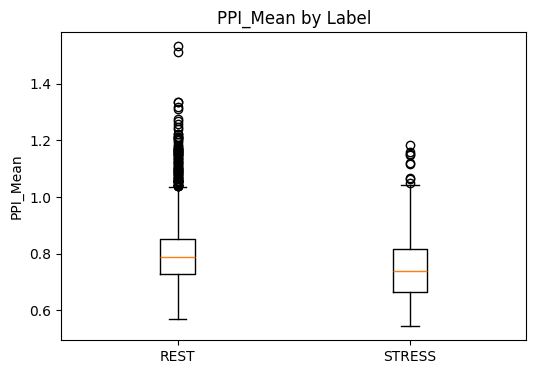

/tmp/ipykernel_1876/1929022168.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rest_values, stress_values], labels=["REST", "STRESS"])


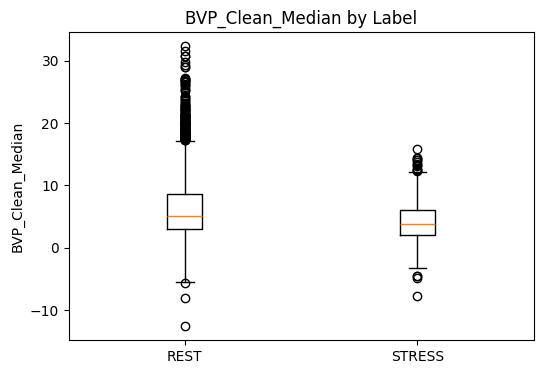

/tmp/ipykernel_1876/1929022168.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rest_values, stress_values], labels=["REST", "STRESS"])


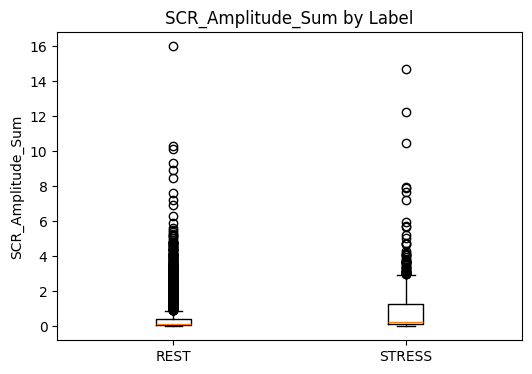

/tmp/ipykernel_1876/1929022168.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rest_values, stress_values], labels=["REST", "STRESS"])


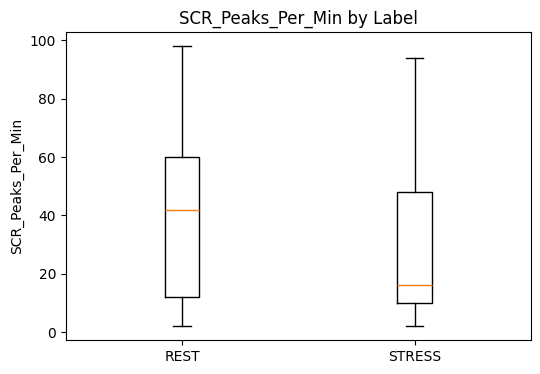

/tmp/ipykernel_1876/1929022168.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rest_values, stress_values], labels=["REST", "STRESS"])


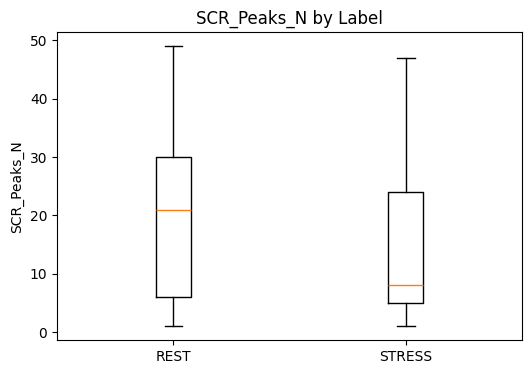

In [22]:
top_features = comparison_df.head(12)["feature"].tolist()

for feature in top_features:
    plt.figure(figsize=(6, 4))

    rest_values = df.loc[df["label"] == "REST", feature].dropna()
    stress_values = df.loc[df["label"] == "STRESS", feature].dropna()

    plt.boxplot([rest_values, stress_values], labels=["REST", "STRESS"])
    plt.title(f"{feature} by Label")
    plt.ylabel(feature)
    plt.show()

## 6. Feature Ranking

### 6.1 Mutual information

In [23]:
imputer = SimpleImputer(strategy="median")
X_mi = imputer.fit_transform(X)

mi_scores = mutual_info_classif(
    X_mi,
    y,
    discrete_features=False,
    random_state=42
)

mi_df = pd.DataFrame({
    "feature": feature_cols,
    "group": [get_feature_group(col) for col in feature_cols],
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False)

display(mi_df.head(40))

,feature,group,mutual_information
121,ACC_Jerk_Max,ACC,0.071083
120,ACC_Jerk_Min,ACC,0.069739
111,ACC_Mag_Max,ACC,0.065869
40,EDA_Raw_Max,EDA,0.065628
132,PPG_Rate_Mean_DeltaBaseline,PPG_HRV,0.065103
123,ACC_Mag_P25,ACC,0.064153
39,EDA_Raw_Min,EDA,0.061119
108,ACC_Mag_Median,ACC,0.059489
37,EDA_Raw_Median,EDA,0.056779
130,SCR_Peaks_N_DeltaBaseline,EDA,0.056370


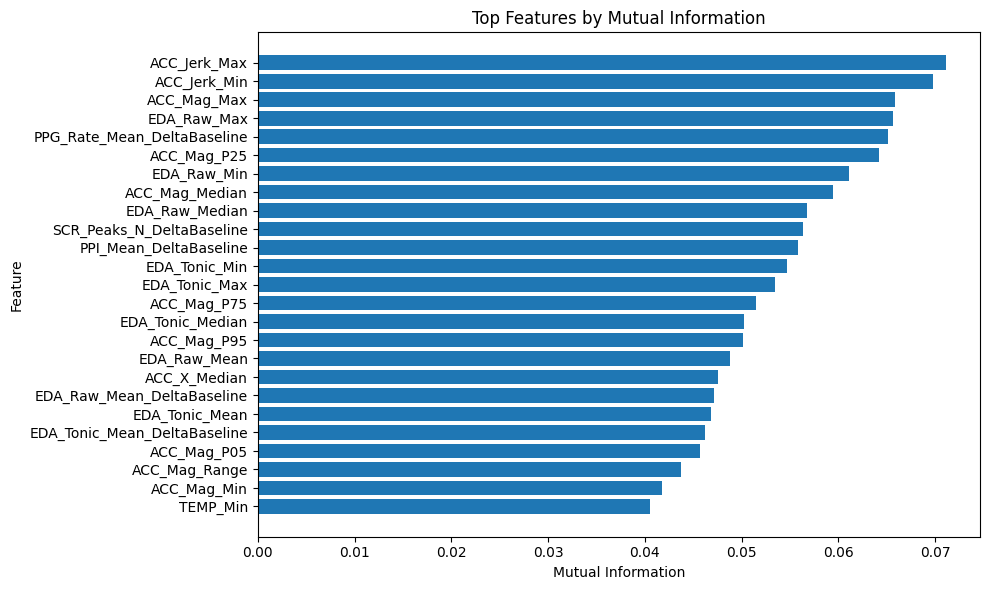

In [24]:
plt.figure(figsize=(10, 6))
top_mi = mi_df.head(25).iloc[::-1]

plt.barh(top_mi["feature"], top_mi["mutual_information"])
plt.title("Top Features by Mutual Information")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [25]:
mi_df.to_csv(DATA_DIR / "features_mutual_information.csv", index=False)

### 6.2 Random Forest importance

In [26]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    max_depth=None
)

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", rf)
])

rf_pipeline.fit(X, y)

rf_importances = rf_pipeline.named_steps["rf"].feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "group": [get_feature_group(col) for col in feature_cols],
    "rf_importance": rf_importances
}).sort_values("rf_importance", ascending=False)

display(rf_importance_df.head(40))

,feature,group,rf_importance
133,PPI_Mean_DeltaBaseline,PPG_HRV,0.040536
132,PPG_Rate_Mean_DeltaBaseline,PPG_HRV,0.040334
60,EDA_Tonic_Slope,EDA,0.030317
1,BVP_Clean_Median,PPG_HRV,0.019498
131,SCR_Amplitude_Mean_DeltaBaseline,EDA,0.018343
19,PPI_Median,PPG_HRV,0.016983
12,PPG_Rate_Mean,PPG_HRV,0.016401
23,HRV_MeanNN,PPG_HRV,0.014356
18,PPI_Mean,PPG_HRV,0.012674
126,TEMP_Mean_DeltaBaseline,TEMP,0.012297


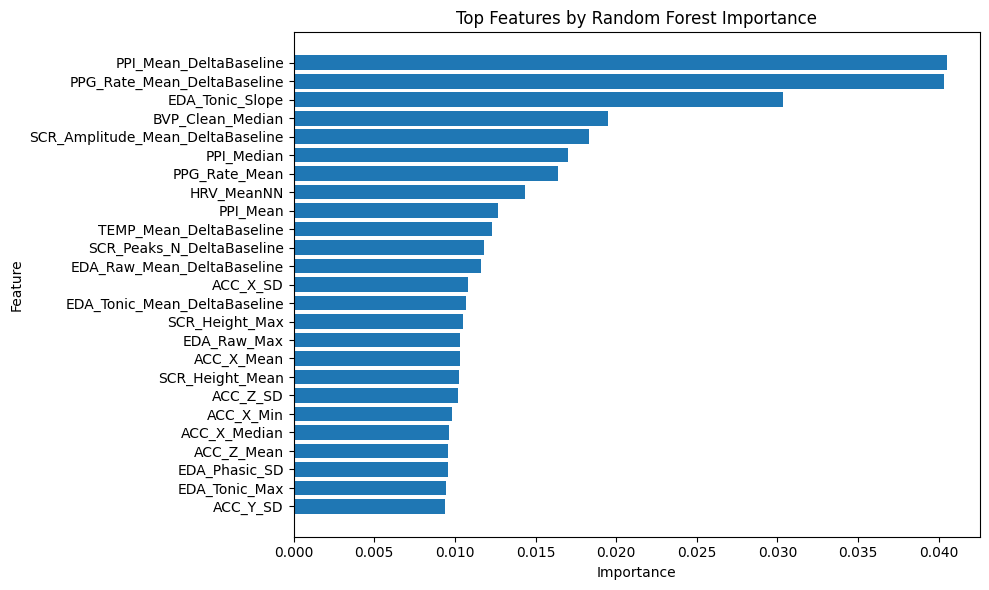

In [27]:
plt.figure(figsize=(10, 6))
top_rf = rf_importance_df.head(25).iloc[::-1]

plt.barh(top_rf["feature"], top_rf["rf_importance"])
plt.title("Top Features by Random Forest Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [28]:
rf_importance_df.to_csv(DATA_DIR / "features_random_forest_importance.csv", index=False)

### 6.3 Correlation-aware feature filtering

Highly correlated features are filtered using the mutual-information ranking to retain the more informative member of each pair.

In [34]:
def correlation_filter(X_df, ranking_df, threshold=0.95):
    """
    Removes one feature from each highly correlated pair.
    Keeps the feature with higher mutual information when possible.
    """
    corr_matrix = X_df.corr(method="spearman").abs()

    ranking = dict(
        zip(ranking_df["feature"], ranking_df["mutual_information"])
    )

    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    to_drop = set()

    for col in upper.columns:
        high_corr_features = upper.index[upper[col] > threshold].tolist()

        for row_feature in high_corr_features:
            feature_a = row_feature
            feature_b = col

            if feature_a in to_drop or feature_b in to_drop:
                continue

            score_a = ranking.get(feature_a, 0)
            score_b = ranking.get(feature_b, 0)

            if score_a >= score_b:
                to_drop.add(feature_b)
            else:
                to_drop.add(feature_a)

    selected = [col for col in X_df.columns if col not in to_drop]

    return selected, sorted(list(to_drop))


selected_after_corr, dropped_corr = correlation_filter(
    X_imputed,
    mi_df,
    threshold=0.95
)

print("Original features:", len(feature_cols))
print("Selected after correlation filter:", len(selected_after_corr))
print("Dropped due to correlation:", len(dropped_corr))

display(pd.DataFrame({"dropped_feature": dropped_corr}))

Original features: 137
Selected after correlation filter: 89
Dropped due to correlation: 48


,dropped_feature
0,ACC_Energy
1,ACC_Jerk_Min
2,ACC_Jerk_SD
3,ACC_Mag_Mean
4,ACC_Mag_Range
5,ACC_RMS
6,ACC_X_Mean
7,ACC_X_Range
8,ACC_Y_Median
9,ACC_Z_Median


In [35]:
feature_selection_df = pd.DataFrame({"feature": feature_cols})

feature_selection_df["group"] = feature_selection_df["feature"].apply(get_feature_group)

feature_selection_df = feature_selection_df.merge(
    comparison_df[["feature", "effect_size", "abs_effect_size", "p_value"]],
    on="feature",
    how="left"
)

feature_selection_df = feature_selection_df.merge(
    mi_df[["feature", "mutual_information"]],
    on="feature",
    how="left"
)

feature_selection_df = feature_selection_df.merge(
    rf_importance_df[["feature", "rf_importance"]],
    on="feature",
    how="left"
)

feature_selection_df["dropped_by_corr_filter"] = feature_selection_df["feature"].isin(dropped_corr)
feature_selection_df["selected_after_corr_filter"] = feature_selection_df["feature"].isin(selected_after_corr)

feature_selection_df = feature_selection_df.sort_values(
    ["selected_after_corr_filter", "mutual_information", "rf_importance", "abs_effect_size"],
    ascending=[False, False, False, False]
)

display(feature_selection_df.head(60))

,feature,group,effect_size,abs_effect_size,p_value,mutual_information,rf_importance,dropped_by_corr_filter,selected_after_corr_filter
121,ACC_Jerk_Max,ACC,0.063743,0.063743,6.493565e-06,0.071083,0.005786,False,True
111,ACC_Mag_Max,ACC,0.018149,0.018149,9.195457e-02,0.065869,0.004441,False,True
40,EDA_Raw_Max,EDA,0.226859,0.226859,5.155138e-19,0.065628,0.010342,False,True
132,PPG_Rate_Mean_DeltaBaseline,PPG_HRV,0.919847,0.919847,6.619321e-65,0.065103,0.040334,False,True
123,ACC_Mag_P25,ACC,-0.190432,0.190432,2.815772e-04,0.064153,0.006424,False,True
108,ACC_Mag_Median,ACC,-0.213034,0.213034,9.807589e-05,0.059489,0.006527,False,True
130,SCR_Peaks_N_DeltaBaseline,EDA,-0.576385,0.576385,6.495699e-35,0.056370,0.011813,False,True
124,ACC_Mag_P75,ACC,-0.206906,0.206906,1.481684e-04,0.051437,0.006673,False,True
125,ACC_Mag_P95,ACC,-0.162027,0.162027,4.859511e-03,0.050153,0.008021,False,True
84,ACC_X_Median,ACC,0.017054,0.017054,7.403726e-01,0.047543,0.009605,False,True


In [36]:
feature_selection_df.to_csv(DATA_DIR / "feature_selection_summary.csv", index=False)

In [37]:
all_clean_features = feature_cols
reduced_features = selected_after_corr

print("All clean features:", len(all_clean_features))
print("Reduced features:", len(reduced_features))

All clean features: 137
Reduced features: 89


In [38]:
pd.Series(all_clean_features).to_csv(DATA_DIR / "feature_set_all_clean.csv", index=False, header=["feature"])
pd.Series(reduced_features).to_csv(DATA_DIR / "feature_set_reduced_corr095.csv", index=False, header=["feature"])

## 7. Preliminary Feature-Set and Model Screening

The following GroupKFold experiments are exploratory checks used to compare broad feature sets and candidate model families. They are **not the final reported evaluation**; the leakage-free nested procedure is defined later in the notebook.

In [39]:
def evaluate_feature_set(feature_list, name):
    X_eval = df[feature_list]
    y_eval = df["label"].map({"REST": 0, "STRESS": 1})
    groups_eval = df["participant_id"]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ])

    cv = GroupKFold(n_splits=5)

    scoring = {
        "balanced_accuracy": make_scorer(balanced_accuracy_score),
        "macro_f1": make_scorer(f1_score, average="macro"),
        "stress_recall": make_scorer(recall_score, pos_label=1),
    }

    scores = cross_validate(
        model,
        X_eval,
        y_eval,
        groups=groups_eval,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    result = {
        "feature_set": name,
        "n_features": len(feature_list),
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": scores["test_balanced_accuracy"].std(),
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_std": scores["test_macro_f1"].std(),
        "stress_recall_mean": scores["test_stress_recall"].mean(),
        "stress_recall_std": scores["test_stress_recall"].std(),
    }

    return result


quick_results = pd.DataFrame([
    evaluate_feature_set(all_clean_features, "all_clean_features"),
])

display(quick_results)

,feature_set,n_features,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,stress_recall_mean,stress_recall_std
0,all_clean_features,137,0.564667,0.042845,0.574431,0.060383,0.135829,0.092332


In [40]:
quick_results.to_csv(DATA_DIR / "eda_quick_groupcv_feature_set_check.csv", index=False)

### 7.1 Participant-wise GroupKFold diagnostic

In [41]:
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score, f1_score, recall_score, precision_score

In [42]:
feature_list = all_clean_features

X_eval = df[feature_list]
y_eval = df["label"].map({"REST": 0, "STRESS": 1})
groups_eval = df["participant_id"]

cv = GroupKFold(n_splits=5)

fold_results = []
all_y_true = []
all_y_pred = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_eval, y_eval, groups_eval), start=1):
    X_train, X_test = X_eval.iloc[train_idx], X_eval.iloc[test_idx]
    y_train, y_test = y_eval.iloc[train_idx], y_eval.iloc[test_idx]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            class_weight="balanced_subsample",
            n_jobs=-1,
            min_samples_leaf=3
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    rest_recall = cm[0, 0] / cm[0].sum() if cm[0].sum() > 0 else np.nan
    stress_recall = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else np.nan

    fold_results.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "test_rest": int((y_test == 0).sum()),
        "test_stress": int((y_test == 1).sum()),
        "rest_recall": rest_recall,
        "stress_recall": stress_recall,
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "confusion_matrix": cm
    })

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

fold_results_df = pd.DataFrame(fold_results)

display(fold_results_df.drop(columns=["confusion_matrix"]))

for row in fold_results:
    print(f"\nFold {row['fold']} confusion matrix")
    print("Rows=true, columns=predicted; labels=[REST, STRESS]")
    print(row["confusion_matrix"])

,fold,n_train,n_test,test_rest,test_stress,rest_recall,stress_recall,balanced_accuracy,macro_f1
0,1,3638,902,777,125,1.000000,0.088000,0.544000,0.546710
1,2,3637,903,772,131,0.994819,0.251908,0.623364,0.665293
2,3,3659,881,755,126,0.933775,0.380952,0.657364,0.672673
3,4,3610,930,793,137,0.987390,0.306569,0.646980,0.690804
4,5,3616,924,805,119,0.985093,0.126050,0.555572,0.568662



Fold 1 confusion matrix
Rows=true, columns=predicted; labels=[REST, STRESS]
[[777   0]
 [114  11]]

Fold 2 confusion matrix
Rows=true, columns=predicted; labels=[REST, STRESS]
[[768   4]
 [ 98  33]]

Fold 3 confusion matrix
Rows=true, columns=predicted; labels=[REST, STRESS]
[[705  50]
 [ 78  48]]

Fold 4 confusion matrix
Rows=true, columns=predicted; labels=[REST, STRESS]
[[783  10]
 [ 95  42]]

Fold 5 confusion matrix
Rows=true, columns=predicted; labels=[REST, STRESS]
[[793  12]
 [104  15]]


### 7.2 Targeted physiological feature set

In [43]:
targeted_keywords = [
    "EDA",
    "SCR",
    "PPG_Rate",
    "PPI",
    "HRV_RMSSD",
    "HRV_SDNN",
    "HRV_SDSD",
    "HRV_pNN",
    "HRV_SD1",
    "HRV_SD2",
    "TEMP",
    "ACC_Mag",
    "ACC_SMA",
    "ACC_Jerk",
    "DeltaBaseline"
]

targeted_features = [
    col for col in all_clean_features
    if any(key in col for key in targeted_keywords)
]

print("Targeted features:", len(targeted_features))
print(targeted_features)

pd.Series(targeted_features).to_csv(
    DATA_DIR / "final_targeted_physiological_features.csv",
    index=False,
    header=["feature"]
)

Targeted features: 92
['PPG_Rate_Mean', 'PPG_Rate_SD', 'PPG_Rate_Min', 'PPG_Rate_Max', 'PPI_Mean', 'PPI_Median', 'PPI_SD', 'PPI_Min', 'PPI_Max', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_pNN20', 'HRV_pNN50', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2', 'EDA_Raw_Mean', 'EDA_Raw_Median', 'EDA_Raw_SD', 'EDA_Raw_Min', 'EDA_Raw_Max', 'EDA_Raw_Range', 'EDA_Raw_Skew', 'EDA_Raw_Kurtosis', 'EDA_Tonic_Mean', 'EDA_Tonic_Median', 'EDA_Tonic_SD', 'EDA_Tonic_Min', 'EDA_Tonic_Max', 'EDA_Tonic_Range', 'EDA_Tonic_Skew', 'EDA_Tonic_Kurtosis', 'EDA_Phasic_Mean', 'EDA_Phasic_Median', 'EDA_Phasic_SD', 'EDA_Phasic_Min', 'EDA_Phasic_Max', 'EDA_Phasic_Range', 'EDA_Phasic_Skew', 'EDA_Phasic_Kurtosis', 'EDA_Tonic_Slope', 'EDA_Phasic_AUC', 'SCR_Peaks_N', 'SCR_Peaks_Per_Min', 'SCR_Presence', 'SCR_Amplitude_Mean', 'SCR_Amplitude_Max', 'SCR_Amplitude_Sum', 'SCR_Height_Mean', 'SCR_Height_Max', 'SCR_RiseTime_Mean', 'SCR_RecoveryTime_Mean', 'TEMP_Mean', 'TEMP_Median', 'TEMP_SD', 'TEMP_Min', 'TEMP_Max', 'TEMP_Range', 'TEMP_Skew

In [44]:
quick_results_2 = pd.DataFrame([
    evaluate_feature_set(all_clean_features, "all_clean_features"),
    evaluate_feature_set(targeted_features, "targeted_physiological_features"),
])

display(quick_results_2)

,feature_set,n_features,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,stress_recall_mean,stress_recall_std
0,all_clean_features,137,0.564667,0.042845,0.574431,0.060383,0.135829,0.092332
1,targeted_physiological_features,92,0.577250,0.030959,0.597051,0.045534,0.160656,0.066066


### 7.3 Exploratory model-family screening

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, balanced_accuracy_score, f1_score, recall_score

models = {
    "LogisticRegression_balanced": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]),

    "SVM_RBF_balanced": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]),

    "RandomForest_balanced": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced_subsample",
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "ExtraTrees_balanced": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", ExtraTreesClassifier(
            n_estimators=500,
            class_weight="balanced",
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ]),
}

scoring = {
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "macro_f1": make_scorer(f1_score, average="macro"),
    "stress_recall": make_scorer(recall_score, pos_label=1),
}

model_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        df[all_clean_features],
        y_eval,
        groups=groups_eval,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    model_results.append({
        "model": model_name,
        "features": "all_clean_features",
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": scores["test_balanced_accuracy"].std(),
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_std": scores["test_macro_f1"].std(),
        "stress_recall_mean": scores["test_stress_recall"].mean(),
        "stress_recall_std": scores["test_stress_recall"].std(),
    })

model_results_df = pd.DataFrame(model_results)
display(model_results_df.sort_values("balanced_accuracy_mean", ascending=False))

,model,features,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,stress_recall_mean,stress_recall_std
1,SVM_RBF_balanced,all_clean_features,0.673579,0.075160,0.647890,0.075877,0.495596,0.162256
0,LogisticRegression_balanced,all_clean_features,0.670424,0.016949,0.596198,0.027562,0.608029,0.042810
3,ExtraTrees_balanced,all_clean_features,0.632598,0.035959,0.657936,0.037510,0.302165,0.113671
2,RandomForest_balanced,all_clean_features,0.605456,0.046914,0.628828,0.059087,0.230696,0.109633


## 8. Combined Feature Ranking

The combined score integrates mutual information, Random Forest importance, REST-vs-STRESS effect magnitude, and a small interpretability component. Correlation-aware selection is then used to construct compact candidate sets.

In [46]:
def interpretability_score(feature):
    """
    Small physiological interpretability score.
    This helps the selected feature set stay explainable.
    """

    if feature.startswith(("EDA", "SCR")):
        score = 1.00

    elif (
        feature.startswith("PPG_Rate") or
        feature.startswith("PPI") or
        feature.startswith("HRV_RMSSD") or
        feature.startswith("HRV_SDNN") or
        feature.startswith("HRV_SDSD") or
        feature.startswith("HRV_pNN") or
        feature.startswith("HRV_SD1") or
        feature.startswith("HRV_SD2")
    ):
        score = 1.00

    elif feature.startswith("TEMP"):
        score = 0.80

    elif (
        feature.startswith("ACC_Mag") or
        feature.startswith("ACC_SMA") or
        feature.startswith("ACC_Jerk") or
        feature.startswith("ACC_RMS") or
        feature.startswith("ACC_Energy")
    ):
        score = 0.75

    elif feature.startswith("BVP"):
        score = 0.65

    elif feature.startswith(("ACC_X", "ACC_Y", "ACC_Z")):
        score = 0.50

    else:
        score = 0.40

    if "DeltaBaseline" in feature:
        score += 0.15

    if feature.endswith(("Skew", "Kurtosis")):
        score -= 0.15

    return max(0.0, min(score, 1.0))

In [47]:
combined_rank_df = pd.DataFrame({"feature": all_clean_features})

combined_rank_df["group"] = combined_rank_df["feature"].apply(get_feature_group)

combined_rank_df = combined_rank_df.merge(
    mi_df[["feature", "mutual_information"]],
    on="feature",
    how="left"
)

combined_rank_df = combined_rank_df.merge(
    rf_importance_df[["feature", "rf_importance"]],
    on="feature",
    how="left"
)

combined_rank_df = combined_rank_df.merge(
    comparison_df[["feature", "effect_size", "abs_effect_size", "p_value"]],
    on="feature",
    how="left"
)

combined_rank_df["interpretability_score"] = combined_rank_df["feature"].apply(
    interpretability_score
)

for col in ["mutual_information", "rf_importance", "abs_effect_size"]:
    combined_rank_df[col] = combined_rank_df[col].fillna(0)

In [48]:
# scores to percentile ranks
combined_rank_df["mi_rank"] = combined_rank_df["mutual_information"].rank(
    pct=True,
    ascending=True
)

combined_rank_df["rf_rank"] = combined_rank_df["rf_importance"].rank(
    pct=True,
    ascending=True
)

combined_rank_df["effect_rank"] = combined_rank_df["abs_effect_size"].rank(
    pct=True,
    ascending=True
)

combined_rank_df["interpretability_rank"] = combined_rank_df["interpretability_score"].rank(
    pct=True,
    ascending=True
)

# final combined score
combined_rank_df["combined_score"] = (
    0.35 * combined_rank_df["mi_rank"] +
    0.35 * combined_rank_df["rf_rank"] +
    0.20 * combined_rank_df["effect_rank"] +
    0.10 * combined_rank_df["interpretability_rank"]
)

combined_rank_df = combined_rank_df.sort_values(
    "combined_score",
    ascending=False
).reset_index(drop=True)

display(combined_rank_df.head(50))

combined_rank_df.to_csv(
    DATA_DIR / "combined_feature_ranking.csv",
    index=False
)

,feature,group,mutual_information,rf_importance,effect_size,abs_effect_size,p_value,interpretability_score,mi_rank,rf_rank,effect_rank,interpretability_rank,combined_score
0,PPG_Rate_Mean_DeltaBaseline,PPG_HRV,0.065103,0.040334,0.919847,0.919847,6.619321e-65,1.00,0.970803,0.992701,1.000000,0.799270,0.967153
1,PPI_Mean_DeltaBaseline,PPG_HRV,0.055806,0.040536,-0.753477,0.753477,1.138303e-57,1.00,0.927007,1.000000,0.992701,0.799270,0.952920
2,SCR_Peaks_N_DeltaBaseline,EDA,0.056370,0.011813,-0.576385,0.576385,6.495699e-35,1.00,0.934307,0.927007,0.978102,0.799270,0.927007
3,EDA_Raw_Max,EDA,0.065628,0.010342,0.226859,0.226859,5.155138e-19,1.00,0.978102,0.890511,0.781022,0.799270,0.890146
4,PPG_Rate_Mean,PPG_HRV,0.030609,0.016401,0.578705,0.578705,2.154899e-31,1.00,0.751825,0.956204,0.985401,0.799270,0.874818
5,EDA_Raw_Mean_DeltaBaseline,EDA,0.047108,0.011625,0.247799,0.247799,3.409604e-22,1.00,0.868613,0.919708,0.788321,0.799270,0.863504
6,SCR_Amplitude_Mean_DeltaBaseline,EDA,0.029616,0.018343,0.385909,0.385909,1.155300e-30,1.00,0.744526,0.970803,0.883212,0.799270,0.856934
7,EDA_Tonic_Mean_DeltaBaseline,EDA,0.046251,0.010684,0.248005,0.248005,3.099350e-22,1.00,0.854015,0.905109,0.795620,0.799270,0.854745
8,PPI_Mean,PPG_HRV,0.027037,0.012674,-0.475787,0.475787,2.732751e-29,1.00,0.715328,0.941606,0.948905,0.799270,0.849635
9,EDA_Tonic_Slope,EDA,0.025139,0.030317,0.368030,0.368030,4.799584e-44,1.00,0.693431,0.985401,0.868613,0.799270,0.841241


In [49]:
def select_top_n_correlation_aware(
    ranking_df,
    X_corr_source,
    n_features=30,
    corr_threshold=0.95
):
    """
    Selects top N features by combined score while skipping highly correlated duplicates.
    """
    selected = []
    corr_matrix = X_corr_source.corr(method="spearman").abs()

    for feature in ranking_df["feature"]:
        if feature not in corr_matrix.columns:
            continue

        if len(selected) == 0:
            selected.append(feature)
        else:
            max_corr = corr_matrix.loc[feature, selected].max()

            if max_corr < corr_threshold:
                selected.append(feature)

        if len(selected) == n_features:
            break

    return selected

In [50]:
top_30_features = select_top_n_correlation_aware(
    combined_rank_df,
    X_imputed,
    n_features=30,
    corr_threshold=0.95
)

top_50_features = select_top_n_correlation_aware(
    combined_rank_df,
    X_imputed,
    n_features=50,
    corr_threshold=0.95
)

print("Top 30 features:", len(top_30_features))
print(top_30_features)

print("\nTop 50 features:", len(top_50_features))
print(top_50_features)

Top 30 features: 30
['PPG_Rate_Mean_DeltaBaseline', 'SCR_Peaks_N_DeltaBaseline', 'EDA_Raw_Max', 'PPG_Rate_Mean', 'EDA_Raw_Mean_DeltaBaseline', 'SCR_Amplitude_Mean_DeltaBaseline', 'EDA_Tonic_Slope', 'EDA_Phasic_SD', 'BVP_Clean_Median', 'ACC_Mag_P95', 'ACC_Mag_Median', 'ACC_Mag_P75', 'ACC_Mag_P25', 'ACC_Z_Mean', 'TEMP_Mean_DeltaBaseline', 'TEMP_Median', 'ACC_Y_Mean', 'ACC_X_SD', 'EDA_Raw_SD', 'ACC_SMA', 'ACC_Z_Min', 'ACC_X_Median', 'ACC_X_Min', 'ACC_Jerk_Min', 'HRV_pNN50', 'PPI_Min', 'ACC_Y_SD', 'SCR_RiseTime_Mean', 'SCR_Peaks_N', 'HRV_pNN20']

Top 50 features: 50
['PPG_Rate_Mean_DeltaBaseline', 'SCR_Peaks_N_DeltaBaseline', 'EDA_Raw_Max', 'PPG_Rate_Mean', 'EDA_Raw_Mean_DeltaBaseline', 'SCR_Amplitude_Mean_DeltaBaseline', 'EDA_Tonic_Slope', 'EDA_Phasic_SD', 'BVP_Clean_Median', 'ACC_Mag_P95', 'ACC_Mag_Median', 'ACC_Mag_P75', 'ACC_Mag_P25', 'ACC_Z_Mean', 'TEMP_Mean_DeltaBaseline', 'TEMP_Median', 'ACC_Y_Mean', 'ACC_X_SD', 'EDA_Raw_SD', 'ACC_SMA', 'ACC_Z_Min', 'ACC_X_Median', 'ACC_X_Min', 'ACC

In [51]:
top30_df = combined_rank_df[
    combined_rank_df["feature"].isin(top_30_features)
].copy()

top50_df = combined_rank_df[
    combined_rank_df["feature"].isin(top_50_features)
].copy()

print("Top 30 feature groups:")
display(top30_df["group"].value_counts())

print("Top 50 feature groups:")
display(top50_df["group"].value_counts())

display(top30_df.sort_values("combined_score", ascending=False))

Top 30 feature groups:


,count
group,
ACC,13
EDA,9
PPG_HRV,6
TEMP,2


Top 50 feature groups:


,count
group,
ACC,25
EDA,13
PPG_HRV,10
TEMP,2


,feature,group,mutual_information,rf_importance,effect_size,abs_effect_size,p_value,interpretability_score,mi_rank,rf_rank,effect_rank,interpretability_rank,combined_score
0,PPG_Rate_Mean_DeltaBaseline,PPG_HRV,0.065103,0.040334,0.919847,0.919847,6.619321e-65,1.00,0.970803,0.992701,1.000000,0.799270,0.967153
2,SCR_Peaks_N_DeltaBaseline,EDA,0.056370,0.011813,-0.576385,0.576385,6.495699e-35,1.00,0.934307,0.927007,0.978102,0.799270,0.927007
3,EDA_Raw_Max,EDA,0.065628,0.010342,0.226859,0.226859,5.155138e-19,1.00,0.978102,0.890511,0.781022,0.799270,0.890146
4,PPG_Rate_Mean,PPG_HRV,0.030609,0.016401,0.578705,0.578705,2.154899e-31,1.00,0.751825,0.956204,0.985401,0.799270,0.874818
5,EDA_Raw_Mean_DeltaBaseline,EDA,0.047108,0.011625,0.247799,0.247799,3.409604e-22,1.00,0.868613,0.919708,0.788321,0.799270,0.863504
6,SCR_Amplitude_Mean_DeltaBaseline,EDA,0.029616,0.018343,0.385909,0.385909,1.155300e-30,1.00,0.744526,0.970803,0.883212,0.799270,0.856934
9,EDA_Tonic_Slope,EDA,0.025139,0.030317,0.368030,0.368030,4.799584e-44,1.00,0.693431,0.985401,0.868613,0.799270,0.841241
19,EDA_Phasic_SD,EDA,0.023633,0.009560,0.408232,0.408232,1.053431e-33,1.00,0.656934,0.839416,0.905109,0.799270,0.784672
22,BVP_Clean_Median,PPG_HRV,0.016511,0.019498,-0.438945,0.438945,2.505134e-24,0.65,0.518248,0.978102,0.941606,0.302920,0.742336
24,ACC_Mag_P95,ACC,0.050153,0.008021,-0.162027,0.162027,4.859511e-03,0.75,0.890511,0.715328,0.613139,0.408759,0.725547


In [52]:
pd.Series(top_30_features).to_csv(
    DATA_DIR / "feature_set_top30_combined.csv",
    index=False,
    header=["feature"]
)

pd.Series(top_50_features).to_csv(
    DATA_DIR / "feature_set_top50_combined.csv",
    index=False,
    header=["feature"]
)

top30_df.to_csv(
    DATA_DIR / "feature_set_top30_combined_details.csv",
    index=False
)

top50_df.to_csv(
    DATA_DIR / "feature_set_top50_combined_details.csv",
    index=False
)

In [53]:
quick_results_3 = pd.DataFrame([
    evaluate_feature_set(all_clean_features, "all_clean_features"),
    evaluate_feature_set(targeted_features, "targeted_physiological_features"),
])

display(quick_results_3)

quick_results_3.to_csv(
    DATA_DIR / "quick_groupcv_top_feature_sets.csv",
    index=False
)

,feature_set,n_features,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,stress_recall_mean,stress_recall_std
0,all_clean_features,137,0.564667,0.042845,0.574431,0.060383,0.135829,0.092332
1,targeted_physiological_features,92,0.577250,0.030959,0.597051,0.045534,0.160656,0.066066


## 9. Modality-Balanced Feature Sets

To prevent accelerometer-derived variables from dominating purely by feature count, the final candidate sets use modality quotas: EDA and PPG/HRV receive equal priority, ACC receives fewer slots, and temperature is represented with a smaller quota because it changes more slowly.

In [54]:
def select_top_n_from_group(
    ranking_df,
    X_corr_source,
    group_name,
    n_features,
    already_selected=None,
    corr_threshold=0.95
):
    """
    Selects top-ranked features from one modality group while avoiding
    high correlation with already selected features.
    """
    if already_selected is None:
        already_selected = []

    selected = []
    corr_matrix = X_corr_source.corr(method="spearman").abs()

    group_candidates = ranking_df[
        ranking_df["group"] == group_name
    ]["feature"].tolist()

    for feature in group_candidates:
        if feature not in corr_matrix.columns:
            continue

        comparison_features = already_selected + selected

        if len(comparison_features) == 0:
            selected.append(feature)
        else:
            max_corr = corr_matrix.loc[feature, comparison_features].max()

            if max_corr < corr_threshold:
                selected.append(feature)

        if len(selected) == n_features:
            break

    return selected


def select_balanced_feature_set(
    ranking_df,
    X_corr_source,
    quotas,
    corr_threshold=0.95
):
    """
    Selects a modality-balanced feature set using predefined quotas.
    If one group cannot fill its quota, remaining slots are filled
    from the best remaining features overall.
    """
    selected = []
    target_n = sum(quotas.values())
    corr_matrix = X_corr_source.corr(method="spearman").abs()

    # First pass: select according to group quotas
    for group_name, n_features in quotas.items():
        group_selected = select_top_n_from_group(
            ranking_df=ranking_df,
            X_corr_source=X_corr_source,
            group_name=group_name,
            n_features=n_features,
            already_selected=selected,
            corr_threshold=corr_threshold
        )

        selected.extend(group_selected)

    if len(selected) < target_n:
        for feature in ranking_df["feature"]:
            if feature in selected:
                continue

            if feature not in corr_matrix.columns:
                continue

            if len(selected) == 0:
                selected.append(feature)
            else:
                max_corr = corr_matrix.loc[feature, selected].max()

                if max_corr < corr_threshold:
                    selected.append(feature)

            if len(selected) == target_n:
                break

    return selected

In [55]:
balanced_top30_quotas = {
    "EDA": 10,
    "PPG_HRV": 10,
    "ACC": 6,
    "TEMP": 4,
}

balanced_top50_quotas = {
    "EDA": 17,
    "PPG_HRV": 17,
    "ACC": 8,
    "TEMP": 8,
}

In [56]:
balanced_top30_features = select_balanced_feature_set(
    ranking_df=combined_rank_df,
    X_corr_source=X_imputed,
    quotas=balanced_top30_quotas,
    corr_threshold=0.95
)

balanced_top50_features = select_balanced_feature_set(
    ranking_df=combined_rank_df,
    X_corr_source=X_imputed,
    quotas=balanced_top50_quotas,
    corr_threshold=0.95
)

print("Balanced Top 30:", len(balanced_top30_features))
print(balanced_top30_features)

print("\nBalanced Top 50:", len(balanced_top50_features))
print(balanced_top50_features)

Balanced Top 30: 30
['SCR_Peaks_N_DeltaBaseline', 'EDA_Raw_Max', 'EDA_Raw_Mean_DeltaBaseline', 'SCR_Amplitude_Mean_DeltaBaseline', 'EDA_Tonic_Slope', 'EDA_Phasic_SD', 'EDA_Raw_SD', 'SCR_RiseTime_Mean', 'SCR_Peaks_N', 'SCR_Amplitude_Sum', 'PPG_Rate_Mean_DeltaBaseline', 'PPG_Rate_Mean', 'BVP_Clean_Median', 'HRV_pNN50', 'PPI_Min', 'HRV_pNN20', 'BVP_Clean_SD', 'HRV_RMSSD_DeltaBaseline', 'BVP_Deriv2_SD', 'PPG_Rate_SD', 'ACC_Mag_P95', 'ACC_Mag_Median', 'ACC_Mag_P75', 'ACC_Mag_P25', 'ACC_Z_Mean', 'ACC_Y_Mean', 'TEMP_Mean_DeltaBaseline', 'TEMP_Median', 'TEMP_SD', 'TEMP_Slope']

Balanced Top 50: 50
['SCR_Peaks_N_DeltaBaseline', 'EDA_Raw_Max', 'EDA_Raw_Mean_DeltaBaseline', 'SCR_Amplitude_Mean_DeltaBaseline', 'EDA_Tonic_Slope', 'EDA_Phasic_SD', 'EDA_Raw_SD', 'SCR_RiseTime_Mean', 'SCR_Peaks_N', 'SCR_Amplitude_Sum', 'SCR_RecoveryTime_Mean', 'EDA_Phasic_Median', 'EDA_Phasic_Mean', 'EDA_Raw_Skew', 'EDA_Phasic_Mean_DeltaBaseline', 'EDA_Raw_Kurtosis', 'EDA_Tonic_Skew', 'PPG_Rate_Mean_DeltaBaseline', 'P

In [57]:
balanced_top30_df = combined_rank_df[
    combined_rank_df["feature"].isin(balanced_top30_features)
].copy()

balanced_top50_df = combined_rank_df[
    combined_rank_df["feature"].isin(balanced_top50_features)
].copy()

print("Balanced Top 30 feature groups:")
display(balanced_top30_df["group"].value_counts())

print("Balanced Top 50 feature groups:")
display(balanced_top50_df["group"].value_counts())

print("Balanced Top 30 selected features:")
display(
    balanced_top30_df.sort_values(
        ["group", "combined_score"],
        ascending=[True, False]
    )
)

print("Balanced Top 50 selected features:")
display(
    balanced_top50_df.sort_values(
        ["group", "combined_score"],
        ascending=[True, False]
    )
)

Balanced Top 30 feature groups:


,count
group,
PPG_HRV,10
EDA,10
ACC,6
TEMP,4


Balanced Top 50 feature groups:


,count
group,
PPG_HRV,17
EDA,17
ACC,8
TEMP,8


Balanced Top 30 selected features:


,feature,group,mutual_information,rf_importance,effect_size,abs_effect_size,p_value,interpretability_score,mi_rank,rf_rank,effect_rank,interpretability_rank,combined_score
24,ACC_Mag_P95,ACC,0.050153,0.008021,-0.162027,0.162027,4.859511e-03,0.75,0.890511,0.715328,0.613139,0.408759,0.725547
25,ACC_Mag_Median,ACC,0.059489,0.006527,-0.213034,0.213034,9.807589e-05,0.75,0.948905,0.583942,0.737226,0.408759,0.724818
27,ACC_Mag_P75,ACC,0.051437,0.006673,-0.206906,0.206906,1.481684e-04,0.75,0.905109,0.613139,0.693431,0.408759,0.710949
28,ACC_Mag_P25,ACC,0.064153,0.006424,-0.190432,0.190432,2.815772e-04,0.75,0.963504,0.562044,0.649635,0.408759,0.704745
29,ACC_Z_Mean,ACC,0.025311,0.009562,0.200966,0.200966,1.528276e-03,0.50,0.700730,0.846715,0.686131,0.171533,0.695985
34,ACC_Y_Mean,ACC,0.040060,0.008566,0.095838,0.095838,9.925923e-02,0.50,0.817518,0.781022,0.489051,0.171533,0.674453
2,SCR_Peaks_N_DeltaBaseline,EDA,0.056370,0.011813,-0.576385,0.576385,6.495699e-35,1.00,0.934307,0.927007,0.978102,0.799270,0.927007
3,EDA_Raw_Max,EDA,0.065628,0.010342,0.226859,0.226859,5.155138e-19,1.00,0.978102,0.890511,0.781022,0.799270,0.890146
5,EDA_Raw_Mean_DeltaBaseline,EDA,0.047108,0.011625,0.247799,0.247799,3.409604e-22,1.00,0.868613,0.919708,0.788321,0.799270,0.863504
6,SCR_Amplitude_Mean_DeltaBaseline,EDA,0.029616,0.018343,0.385909,0.385909,1.155300e-30,1.00,0.744526,0.970803,0.883212,0.799270,0.856934


Balanced Top 50 selected features:


,feature,group,mutual_information,rf_importance,effect_size,abs_effect_size,p_value,interpretability_score,mi_rank,rf_rank,effect_rank,interpretability_rank,combined_score
24,ACC_Mag_P95,ACC,0.050153,0.008021,-0.162027,0.162027,4.859511e-03,0.75,0.890511,0.715328,0.613139,0.408759,0.725547
25,ACC_Mag_Median,ACC,0.059489,0.006527,-0.213034,0.213034,9.807589e-05,0.75,0.948905,0.583942,0.737226,0.408759,0.724818
27,ACC_Mag_P75,ACC,0.051437,0.006673,-0.206906,0.206906,1.481684e-04,0.75,0.905109,0.613139,0.693431,0.408759,0.710949
28,ACC_Mag_P25,ACC,0.064153,0.006424,-0.190432,0.190432,2.815772e-04,0.75,0.963504,0.562044,0.649635,0.408759,0.704745
29,ACC_Z_Mean,ACC,0.025311,0.009562,0.200966,0.200966,1.528276e-03,0.50,0.700730,0.846715,0.686131,0.171533,0.695985
34,ACC_Y_Mean,ACC,0.040060,0.008566,0.095838,0.095838,9.925923e-02,0.50,0.817518,0.781022,0.489051,0.171533,0.674453
38,ACC_X_SD,ACC,0.017901,0.010832,-0.195823,0.195823,4.993603e-01,0.50,0.554745,0.912409,0.671533,0.171533,0.664964
40,ACC_SMA,ACC,0.025976,0.008319,0.102242,0.102242,6.019608e-02,0.75,0.708029,0.759124,0.496350,0.408759,0.653650
2,SCR_Peaks_N_DeltaBaseline,EDA,0.056370,0.011813,-0.576385,0.576385,6.495699e-35,1.00,0.934307,0.927007,0.978102,0.799270,0.927007
3,EDA_Raw_Max,EDA,0.065628,0.010342,0.226859,0.226859,5.155138e-19,1.00,0.978102,0.890511,0.781022,0.799270,0.890146


In [58]:
pd.Series(balanced_top30_features).to_csv(
    DATA_DIR / "feature_set_balanced_top30.csv",
    index=False,
    header=["feature"]
)

pd.Series(balanced_top50_features).to_csv(
    DATA_DIR / "feature_set_balanced_top50.csv",
    index=False,
    header=["feature"]
)

balanced_top30_df.to_csv(
    DATA_DIR / "feature_set_balanced_top30_details.csv",
    index=False
)

balanced_top50_df.to_csv(
    DATA_DIR / "feature_set_balanced_top50_details.csv",
    index=False
)

## 10. Leakage-Free Nested Participant-Wise Evaluation

This is the **primary model-evaluation procedure**. In every outer GroupKFold split, feature ranking and modality-balanced selection are rebuilt using only outer-training participants. Decision thresholds are then selected through an inner participant-wise GroupKFold using only the outer-training data. The outer-test participants are used only for final fold evaluation.

### 10.1 Train-only feature ranking

In [59]:
def build_feature_ranking_train_only(X_train, y_train):
    """
    Build the combined feature ranking using ONLY the supplied
    training participants.
    """

    # Median imputation fitted only on training data
    imputer = SimpleImputer(strategy="median")

    X_imp = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    # Mutual information
    mi_scores = mutual_info_classif(
        X_imp,
        y_train.to_numpy(),
        discrete_features=False,
        random_state=42
    )

    # Random Forest importance
    rf_ranker = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    rf_ranker.fit(X_imp, y_train)

    # REST vs STRESS effect sizes
    effect_rows = []

    for feature in X_train.columns:

        rest_values = X_train.loc[
            y_train == 0, feature
        ].dropna()

        stress_values = X_train.loc[
            y_train == 1, feature
        ].dropna()

        effect = compute_effect_size(
            rest_values,
            stress_values
        )

        effect_rows.append({
            "feature": feature,
            "effect_size": effect,
            "abs_effect_size":
                abs(effect) if pd.notna(effect) else 0.0
        })

    effect_df = pd.DataFrame(effect_rows)

    # Build ranking dataframe
    ranking = pd.DataFrame({
        "feature": X_train.columns,
        "group": [
            get_feature_group(col)
            for col in X_train.columns
        ],
        "mutual_information": mi_scores,
        "rf_importance": rf_ranker.feature_importances_
    })

    ranking = ranking.merge(
        effect_df,
        on="feature",
        how="left"
    )

    ranking["interpretability_score"] = (
        ranking["feature"].apply(
            interpretability_score
        )
    )

    for col in [
        "mutual_information",
        "rf_importance",
        "abs_effect_size"
    ]:
        ranking[col] = ranking[col].fillna(0)

    ranking["mi_rank"] = (
        ranking["mutual_information"].rank(pct=True)
    )

    ranking["rf_rank"] = (
        ranking["rf_importance"].rank(pct=True)
    )

    ranking["effect_rank"] = (
        ranking["abs_effect_size"].rank(pct=True)
    )

    ranking["interpretability_rank"] = (
        ranking["interpretability_score"].rank(pct=True)
    )

    ranking["combined_score"] = (
        0.35 * ranking["mi_rank"]
        + 0.35 * ranking["rf_rank"]
        + 0.20 * ranking["effect_rank"]
        + 0.10 * ranking["interpretability_rank"]
    )

    ranking = ranking.sort_values(
        "combined_score",
        ascending=False
    ).reset_index(drop=True)

    return ranking, X_imp

### 10.2 Model definitions and inner-CV threshold selection

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)
from sklearn.metrics import precision_score
from xgboost import XGBClassifier



# MODEL FACTORIES

def make_logistic_regression(y_train=None):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ])


def make_random_forest(y_train=None):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced_subsample",
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ])


def make_svm_rbf(y_train=None):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ])


def make_extra_trees(y_train=None):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", ExtraTreesClassifier(
            n_estimators=500,
            class_weight="balanced",
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ])


def make_xgboost(y_train=None):

    if y_train is None:
        raise ValueError(
            "y_train is required for XGBoost so that "
            "scale_pos_weight is calculated from training data only."
        )

    n_rest = int((y_train == 0).sum())
    n_stress = int((y_train == 1).sum())

    scale_pos_weight = n_rest / n_stress

    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1
        ))
    ])


# THRESHOLD GRID

THRESHOLDS = np.round(
    np.arange(0.05, 0.96, 0.05),
    2
)


# INNER PARTICIPANT-WISE THRESHOLD SELECTION

def choose_threshold_inner_cv(
    X_outer_train,
    y_outer_train,
    groups_outer_train,
    model_factory,
    thresholds=THRESHOLDS
):
    """
    Choose a decision threshold using only participants
    belonging to the outer-training fold.

    Within every inner fold:

    1. Feature ranking is calculated using inner-training
       participants only.
    2. Balanced top-30 is selected using inner-training
       participants only.
    3. The classifier is trained on inner-training participants.
    4. Predictions are generated for inner-validation
       participants.

    The outer-test participants are never used here.
    """

    inner_cv = GroupKFold(n_splits=5)

    inner_true = []
    inner_prob = []

    for inner_train_idx, inner_val_idx in inner_cv.split(
        X_outer_train,
        y_outer_train,
        groups_outer_train
    ):

        X_inner_train = (
            X_outer_train.iloc[inner_train_idx].copy()
        )

        X_inner_val = (
            X_outer_train.iloc[inner_val_idx].copy()
        )

        y_inner_train = (
            y_outer_train.iloc[inner_train_idx].copy()
        )

        y_inner_val = (
            y_outer_train.iloc[inner_val_idx].copy()
        )


        # FEATURE SELECTION — INNER TRAIN ONLY

        ranking_inner, X_inner_train_imp = (
            build_feature_ranking_train_only(
                X_inner_train,
                y_inner_train
            )
        )


        inner_features = select_balanced_feature_set(
            ranking_df=ranking_inner,
            X_corr_source=X_inner_train_imp,
            quotas=balanced_top30_quotas,
            corr_threshold=0.95
        )


        # MODEL — INNER TRAIN ONLY

        # y_inner_train is supplied so XGBoost can calculate
        # scale_pos_weight from this training fold only.
        model = model_factory(
            y_inner_train
        )


        model.fit(
            X_inner_train[inner_features],
            y_inner_train
        )


        probabilities = model.predict_proba(
            X_inner_val[inner_features]
        )[:, 1]


        inner_true.extend(
            y_inner_val.to_numpy()
        )

        inner_prob.extend(
            probabilities
        )


    inner_true = np.asarray(inner_true)
    inner_prob = np.asarray(inner_prob)


    # THRESHOLD COMPARISON

    threshold_rows = []


    for threshold in thresholds:

        predictions = (
            inner_prob >= threshold
        ).astype(int)


        threshold_rows.append({

            "threshold":
                threshold,

            "balanced_accuracy":
                balanced_accuracy_score(
                    inner_true,
                    predictions
                ),

            "macro_f1":
                f1_score(
                    inner_true,
                    predictions,
                    average="macro"
                ),

            "stress_precision":
                precision_score(
                    inner_true,
                    predictions,
                    pos_label=1,
                    zero_division=0
                ),

            "stress_recall":
                recall_score(
                    inner_true,
                    predictions,
                    pos_label=1,
                    zero_division=0
                )
        })


    threshold_df = pd.DataFrame(
        threshold_rows
    )


    # Primary criterion:
    # balanced accuracy
    #
    # Secondary criterion:
    # macro-F1
    threshold_df = threshold_df.sort_values(
        [
            "balanced_accuracy",
            "macro_f1"
        ],
        ascending=[
            False,
            False
        ]
    ).reset_index(drop=True)


    best_threshold = float(
        threshold_df.loc[
            0,
            "threshold"
        ]
    )


    return (
        best_threshold,
        threshold_df
    )

### 10.3 Outer participant-wise nested cross-validation

In [61]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# FINAL LEAKAGE-FREE NESTED PARTICIPANT-WISE EVALUATION
X_final = df[all_clean_features].copy()

y_final = df["label"].map({
    "REST": 0,
    "STRESS": 1
})

groups_final = df["participant_id"]


# Outer CV = final generalisation evaluation
outer_cv = GroupKFold(n_splits=5)


# Models to compare
final_models = {
    "Logistic Regression": make_logistic_regression,
    "Random Forest": make_random_forest,
    "SVM RBF": make_svm_rbf,
    "ExtraTrees": make_extra_trees,
    "XGBoost": make_xgboost,
}


# Store fold-level results
outer_results = []

# Store which features were selected in each fold
selected_feature_records = []

# Store predictions across outer folds
# so we can later build overall confusion matrices
pooled_predictions = {
    model_name: {
        "y_true": [],
        "y_prob": [],
        "y_pred_default": [],
        "y_pred_tuned": []
    }
    for model_name in final_models
}


# OUTER CROSS-VALIDATION

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(
        X_final,
        y_final,
        groups_final
    ),
    start=1
):

    print("\n" + "=" * 60)
    print(f"OUTER FOLD {fold}")
    print("=" * 60)

    # Outer train / test split
    X_outer_train = X_final.iloc[train_idx].copy()
    X_outer_test = X_final.iloc[test_idx].copy()

    y_outer_train = y_final.iloc[train_idx].copy()
    y_outer_test = y_final.iloc[test_idx].copy()

    groups_outer_train = groups_final.iloc[train_idx].copy()
    groups_outer_test = groups_final.iloc[test_idx].copy()


    print(
        "Training participants:",
        groups_outer_train.nunique()
    )

    print(
        "Test participants:",
        groups_outer_test.nunique()
    )


    # FEATURE SELECTION
    # Uses OUTER TRAINING PARTICIPANTS ONLY

    ranking_outer, X_outer_train_imputed = (
        build_feature_ranking_train_only(
            X_outer_train,
            y_outer_train
        )
    )


    outer_features = select_balanced_feature_set(
        ranking_df=ranking_outer,
        X_corr_source=X_outer_train_imputed,
        quotas=balanced_top30_quotas,
        corr_threshold=0.95
    )


    print(
        f"Selected {len(outer_features)} features"
    )


    # Record features selected in this fold
    for feature in outer_features:

        selected_feature_records.append({
            "fold": fold,
            "feature": feature
        })


    # TRAIN + EVALUATE EACH MODEL

    for model_name, model_factory in final_models.items():

        print(f"\nModel: {model_name}")


        # Select threshold using INNER CV
        # Outer test participants are NOT used here

        best_threshold, inner_threshold_results = (
            choose_threshold_inner_cv(
                X_outer_train=X_outer_train,
                y_outer_train=y_outer_train,
                groups_outer_train=groups_outer_train,
                model_factory=model_factory
            )
        )


        print(
            f"Inner-CV selected threshold: "
            f"{best_threshold:.2f}"
        )


        # Train model on ALL outer-training participants
        # using the feature set selected from outer train

        model = model_factory(y_outer_train)

        model.fit(
            X_outer_train[outer_features],
            y_outer_train
        )



        # OUTER TEST IS TOUCHED FOR THE FIRST TIME HERE
        y_prob = model.predict_proba(
            X_outer_test[outer_features]
        )[:, 1]


        # Standard threshold
        y_pred_default = (
            y_prob >= 0.50
        ).astype(int)


        # Inner-CV-selected threshold
        y_pred_tuned = (
            y_prob >= best_threshold
        ).astype(int)


        # SAVE RESULTS FOR BOTH THRESHOLD SETTINGS
        for setting, threshold, y_pred in [

            (
                "default_0.50",
                0.50,
                y_pred_default
            ),

            (
                "nested_tuned",
                best_threshold,
                y_pred_tuned
            )
        ]:

            outer_results.append({

                "fold": fold,

                "model": model_name,

                "setting": setting,

                "threshold": threshold,

                "n_train_participants":
                    groups_outer_train.nunique(),

                "n_test_participants":
                    groups_outer_test.nunique(),

                "n_features":
                    len(outer_features),

                "accuracy":
                    accuracy_score(
                        y_outer_test,
                        y_pred
                    ),

                "balanced_accuracy":
                    balanced_accuracy_score(
                        y_outer_test,
                        y_pred
                    ),

                "macro_f1":
                    f1_score(
                        y_outer_test,
                        y_pred,
                        average="macro"
                    ),

                "stress_precision":
                    precision_score(
                        y_outer_test,
                        y_pred,
                        pos_label=1,
                        zero_division=0
                    ),

                "stress_recall":
                    recall_score(
                        y_outer_test,
                        y_pred,
                        pos_label=1,
                        zero_division=0
                    ),

                # These do not depend on the chosen threshold
                "roc_auc":
                    roc_auc_score(
                        y_outer_test,
                        y_prob
                    ),

                "pr_auc":
                    average_precision_score(
                        y_outer_test,
                        y_prob
                    )
            })


        # SAVE POOLED OUTER-TEST PREDICTIONS
        pooled_predictions[
            model_name
        ]["y_true"].extend(
            y_outer_test.to_numpy()
        )

        pooled_predictions[
            model_name
        ]["y_prob"].extend(
            y_prob
        )

        pooled_predictions[
            model_name
        ]["y_pred_default"].extend(
            y_pred_default
        )

        pooled_predictions[
            model_name
        ]["y_pred_tuned"].extend(
            y_pred_tuned
        )


# CREATE RESULT DATAFRAMES
outer_results_df = pd.DataFrame(
    outer_results
)

selected_features_df = pd.DataFrame(
    selected_feature_records
)


display(outer_results_df)


OUTER FOLD 1
Training participants: 28
Test participants: 7
Selected 30 features

Model: Logistic Regression
Inner-CV selected threshold: 0.50

Model: Random Forest
Inner-CV selected threshold: 0.20

Model: SVM RBF
Inner-CV selected threshold: 0.10

Model: ExtraTrees
Inner-CV selected threshold: 0.25

Model: XGBoost
Inner-CV selected threshold: 0.25

OUTER FOLD 2
Training participants: 28
Test participants: 7
Selected 30 features

Model: Logistic Regression
Inner-CV selected threshold: 0.45

Model: Random Forest
Inner-CV selected threshold: 0.20

Model: SVM RBF
Inner-CV selected threshold: 0.10

Model: ExtraTrees
Inner-CV selected threshold: 0.25

Model: XGBoost
Inner-CV selected threshold: 0.25

OUTER FOLD 3
Training participants: 28
Test participants: 7
Selected 30 features

Model: Logistic Regression
Inner-CV selected threshold: 0.45

Model: Random Forest
Inner-CV selected threshold: 0.25

Model: SVM RBF
Inner-CV selected threshold: 0.15

Model: ExtraTrees
Inner-CV selected thresho

,fold,model,setting,threshold,n_train_participants,n_test_participants,n_features,accuracy,balanced_accuracy,macro_f1,stress_precision,stress_recall,roc_auc,pr_auc
0,1,Logistic Regression,default_0.50,0.50,28,7,30,0.709534,0.787768,0.631060,0.310249,0.896000,0.876057,0.535007
1,1,Logistic Regression,nested_tuned,0.50,28,7,30,0.709534,0.787768,0.631060,0.310249,0.896000,0.876057,0.535007
2,1,Random Forest,default_0.50,0.50,28,7,30,0.880266,0.571356,0.592470,0.947368,0.144000,0.759959,0.486599
3,1,Random Forest,nested_tuned,0.20,28,7,30,0.735033,0.688448,0.612656,0.288889,0.624000,0.759959,0.486599
4,1,SVM RBF,default_0.50,0.50,28,7,30,0.837029,0.522764,0.520135,0.250000,0.088000,0.640247,0.206173
5,1,SVM RBF,nested_tuned,0.10,28,7,30,0.675166,0.583212,0.535182,0.202128,0.456000,0.640247,0.206173
6,1,ExtraTrees,default_0.50,0.50,28,7,30,0.876940,0.609704,0.641452,0.652174,0.240000,0.741725,0.427025
7,1,ExtraTrees,nested_tuned,0.25,28,7,30,0.687361,0.674203,0.580027,0.255452,0.656000,0.741725,0.427025
8,1,XGBoost,default_0.50,0.50,28,7,30,0.815965,0.614589,0.614589,0.336000,0.336000,0.763140,0.397454
9,1,XGBoost,nested_tuned,0.25,28,7,30,0.671840,0.671907,0.570587,0.247788,0.672000,0.763140,0.397454


### 10.4 Nested-CV summaries and exported evaluation tables

In [62]:
# SUMMARY OF FINAL NESTED-CV RESULTS

# 1. Mean ± SD across the 5 outer folds
metrics_to_summarize = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "stress_precision",
    "stress_recall",
    "roc_auc",
    "pr_auc"
]

summary_rows = []

for (model, setting), group in outer_results_df.groupby(
    ["model", "setting"]
):

    row = {
        "model": model,
        "setting": setting,
        "mean_threshold": group["threshold"].mean(),
        "std_threshold": group["threshold"].std(),
    }

    for metric in metrics_to_summarize:
        row[f"{metric}_mean"] = group[metric].mean()
        row[f"{metric}_std"] = group[metric].std()

    summary_rows.append(row)


nested_summary_df = pd.DataFrame(summary_rows)

display(nested_summary_df.round(3))


# 2. THRESHOLDS SELECTED IN EACH OUTER FOLD

thresholds_by_fold = (
    outer_results_df[
        outer_results_df["setting"] == "nested_tuned"
    ][
        ["fold", "model", "threshold"]
    ]
    .sort_values(["model", "fold"])
    .reset_index(drop=True)
)

print("\nThresholds selected by inner CV:")
display(thresholds_by_fold)


# 3. POOLED CONFUSION MATRICES

confusion_rows = []

for model_name in final_models:

    y_true = np.asarray(
        pooled_predictions[model_name]["y_true"]
    )

    for setting, prediction_key in [
        ("default_0.50", "y_pred_default"),
        ("nested_tuned", "y_pred_tuned")
    ]:

        y_pred = np.asarray(
            pooled_predictions[
                model_name
            ][prediction_key]
        )

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        tn, fp, fn, tp = cm.ravel()

        confusion_rows.append({
            "model": model_name,
            "setting": setting,
            "TN_REST": tn,
            "FP_REST_as_STRESS": fp,
            "FN_STRESS_as_REST": fn,
            "TP_STRESS": tp
        })

        print(
            f"\n{model_name} — {setting}"
        )
        print(cm)


confusion_summary_df = pd.DataFrame(
    confusion_rows
)

print("\nPooled confusion-matrix counts:")
display(confusion_summary_df)


# 4. FEATURE-SELECTION STABILITY

feature_selection_frequency = (
    selected_features_df
    .groupby("feature")["fold"]
    .nunique()
    .reset_index(
        name="selected_in_n_folds"
    )
    .sort_values(
        [
            "selected_in_n_folds",
            "feature"
        ],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

feature_selection_frequency[
    "selection_percentage"
] = (
    feature_selection_frequency[
        "selected_in_n_folds"
    ] / 5 * 100
)


print("\nFeature-selection stability:")
display(
    feature_selection_frequency.head(50)
)


# Features selected in at least 4 of 5 folds
stable_features = (
    feature_selection_frequency[
        feature_selection_frequency[
            "selected_in_n_folds"
        ] >= 4
    ]
)

print(
    "\nFeatures selected in at least "
    "4 of the 5 outer folds:"
)

display(stable_features)


# 5. SAVE FINAL TABLES

nested_summary_df.to_csv(
    DATA_DIR / "nested_cv_summary.csv",
    index=False
)

thresholds_by_fold.to_csv(
    DATA_DIR / "nested_thresholds_by_fold.csv",
    index=False
)

confusion_summary_df.to_csv(
    DATA_DIR / "nested_confusion_matrices.csv",
    index=False
)

feature_selection_frequency.to_csv(
    DATA_DIR / "nested_feature_selection_frequency.csv",
    index=False
)

print("\nFinal nested-CV summary files saved.")

,model,setting,mean_threshold,std_threshold,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,stress_precision_mean,stress_precision_std,stress_recall_mean,stress_recall_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,ExtraTrees,default_0.50,0.50,0.000,0.871,0.033,0.648,0.026,0.676,0.035,0.634,0.161,0.337,0.074,0.781,0.048,0.511,0.073
1,ExtraTrees,nested_tuned,0.28,0.045,0.699,0.056,0.699,0.031,0.598,0.048,0.282,0.056,0.698,0.028,0.781,0.048,0.511,0.073
2,Logistic Regression,default_0.50,0.50,0.000,0.715,0.052,0.712,0.043,0.611,0.030,0.294,0.026,0.709,0.122,0.781,0.054,0.435,0.063
3,Logistic Regression,nested_tuned,0.52,0.104,0.708,0.082,0.699,0.054,0.601,0.039,0.299,0.064,0.687,0.190,0.781,0.054,0.435,0.063
4,Random Forest,default_0.50,0.50,0.000,0.880,0.015,0.624,0.036,0.657,0.044,0.757,0.173,0.268,0.084,0.786,0.032,0.515,0.048
5,Random Forest,nested_tuned,0.23,0.027,0.739,0.068,0.707,0.022,0.626,0.047,0.315,0.055,0.664,0.061,0.786,0.032,0.515,0.048
6,SVM RBF,default_0.50,0.50,0.000,0.850,0.019,0.643,0.072,0.649,0.074,0.435,0.110,0.356,0.163,0.749,0.068,0.427,0.129
7,SVM RBF,nested_tuned,0.13,0.045,0.716,0.061,0.669,0.054,0.596,0.043,0.279,0.054,0.605,0.138,0.749,0.068,0.427,0.129
8,XGBoost,default_0.50,0.50,0.000,0.816,0.028,0.683,0.041,0.660,0.034,0.384,0.050,0.500,0.098,0.791,0.027,0.504,0.073
9,XGBoost,nested_tuned,0.28,0.076,0.697,0.087,0.698,0.025,0.597,0.057,0.289,0.061,0.701,0.092,0.791,0.027,0.504,0.073



Thresholds selected by inner CV:


,fold,model,threshold
0,1,ExtraTrees,0.25
1,2,ExtraTrees,0.25
2,3,ExtraTrees,0.35
3,4,ExtraTrees,0.30
4,5,ExtraTrees,0.25
5,1,Logistic Regression,0.50
6,2,Logistic Regression,0.45
7,3,Logistic Regression,0.45
8,4,Logistic Regression,0.50
9,5,Logistic Regression,0.70



Logistic Regression — default_0.50
[[2793 1109]
 [ 185  453]]

Logistic Regression — nested_tuned
[[2777 1125]
 [ 197  441]]

Random Forest — default_0.50
[[3826   76]
 [ 466  172]]

Random Forest — nested_tuned
[[2938  964]
 [ 214  424]]

SVM RBF — default_0.50
[[3628  274]
 [ 409  229]]

SVM RBF — nested_tuned
[[2864 1038]
 [ 249  389]]

ExtraTrees — default_0.50
[[3742  160]
 [ 423  215]]

ExtraTrees — nested_tuned
[[2730 1172]
 [ 193  445]]

XGBoost — default_0.50
[[3385  517]
 [ 318  320]]

XGBoost — nested_tuned
[[2719 1183]
 [ 189  449]]

Pooled confusion-matrix counts:


,model,setting,TN_REST,FP_REST_as_STRESS,FN_STRESS_as_REST,TP_STRESS
0,Logistic Regression,default_0.50,2793,1109,185,453
1,Logistic Regression,nested_tuned,2777,1125,197,441
2,Random Forest,default_0.50,3826,76,466,172
3,Random Forest,nested_tuned,2938,964,214,424
4,SVM RBF,default_0.50,3628,274,409,229
5,SVM RBF,nested_tuned,2864,1038,249,389
6,ExtraTrees,default_0.50,3742,160,423,215
7,ExtraTrees,nested_tuned,2730,1172,193,445
8,XGBoost,default_0.50,3385,517,318,320
9,XGBoost,nested_tuned,2719,1183,189,449



Feature-selection stability:


,feature,selected_in_n_folds,selection_percentage
0,ACC_Mag_Median,5,100.0
1,ACC_Mag_P25,5,100.0
2,ACC_Z_Mean,5,100.0
3,BVP_Clean_Median,5,100.0
4,EDA_Raw_SD,5,100.0
5,EDA_Tonic_Slope,5,100.0
6,HRV_pNN20,5,100.0
7,HRV_pNN50,5,100.0
8,PPG_Rate_Mean,5,100.0
9,PPG_Rate_Mean_DeltaBaseline,5,100.0



Features selected in at least 4 of the 5 outer folds:


,feature,selected_in_n_folds,selection_percentage
0,ACC_Mag_Median,5,100.0
1,ACC_Mag_P25,5,100.0
2,ACC_Z_Mean,5,100.0
3,BVP_Clean_Median,5,100.0
4,EDA_Raw_SD,5,100.0
5,EDA_Tonic_Slope,5,100.0
6,HRV_pNN20,5,100.0
7,HRV_pNN50,5,100.0
8,PPG_Rate_Mean,5,100.0
9,PPG_Rate_Mean_DeltaBaseline,5,100.0



Final nested-CV summary files saved.


## 11. Final Feature Set for Model Training

After evaluation is complete, the same ranking and modality-balanced selection procedure is applied to the full development dataset to create the final 30-feature list used by Notebook 3. This full-data selection is for training the deployable final models, not for estimating generalization performance.

In [63]:
# FINAL FULL-DATA BALANCED TOP-30 FEATURE SET

final_ranking_full, X_final_imputed = (
    build_feature_ranking_train_only(
        X_final,
        y_final
    )
)

final_balanced_top30_features = (
    select_balanced_feature_set(
        ranking_df=final_ranking_full,
        X_corr_source=X_final_imputed,
        quotas=balanced_top30_quotas,
        corr_threshold=0.95
    )
)

print(
    "Final feature count:",
    len(final_balanced_top30_features)
)

print("\nFinal balanced top-30:")
for i, feature in enumerate(
    final_balanced_top30_features,
    start=1
):
    print(f"{i:2d}. {feature}")


# Save final feature list
pd.Series(
    final_balanced_top30_features
).to_csv(
    DATA_DIR / "final_balanced_top30_features.csv",
    index=False,
    header=["feature"]
)


# Also save the full final ranking for reproducibility
final_ranking_full.to_csv(
    DATA_DIR / "final_full_data_feature_ranking.csv",
    index=False
)

print("\nFinal full-data feature set saved.")

Final feature count: 30

Final balanced top-30:
 1. SCR_Peaks_N_DeltaBaseline
 2. EDA_Raw_Max
 3. EDA_Raw_Mean_DeltaBaseline
 4. SCR_Amplitude_Mean_DeltaBaseline
 5. EDA_Tonic_Slope
 6. EDA_Phasic_SD
 7. EDA_Raw_SD
 8. SCR_RiseTime_Mean
 9. SCR_Peaks_N
10. SCR_Amplitude_Sum
11. PPG_Rate_Mean_DeltaBaseline
12. PPG_Rate_Mean
13. BVP_Clean_Median
14. HRV_pNN50
15. PPI_Min
16. HRV_pNN20
17. BVP_Clean_SD
18. HRV_RMSSD_DeltaBaseline
19. BVP_Deriv2_SD
20. PPG_Rate_SD
21. ACC_Mag_P95
22. ACC_Mag_Median
23. ACC_Mag_P75
24. ACC_Mag_P25
25. ACC_Z_Mean
26. ACC_Y_Mean
27. TEMP_Mean_DeltaBaseline
28. TEMP_Median
29. TEMP_SD
30. TEMP_Slope

Final full-data feature set saved.


## 12. Random Window-Level CV: Leakage Diagnostic

This secondary experiment intentionally mixes participants across stratified folds. Because windows overlap by 50% and the same participant can appear in both train and test sets, these results are **not used as the primary performance estimate**. The experiment is retained to demonstrate how random window-level splitting can inflate apparent performance compared with participant-wise evaluation.

In [64]:
# RANDOM WINDOW-LEVEL NESTED CROSS-VALIDATION
# Participants are intentionally mixed across folds

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

participant_outer_results_df = outer_results_df.copy()

X_random = df[all_clean_features].copy()

y_random = df["label"].map({
    "REST": 0,
    "STRESS": 1
})

participants_random = df["participant_id"].copy()


print("Dataset shape:", X_random.shape)
print("REST windows:", int((y_random == 0).sum()))
print("STRESS windows:", int((y_random == 1).sum()))
print("Participants:", participants_random.nunique())

Dataset shape: (4540, 137)
REST windows: 3902
STRESS windows: 638
Participants: 35


In [65]:
# INNER RANDOM WINDOW-LEVEL THRESHOLD SELECTION

def choose_threshold_inner_cv_random(
    X_outer_train,
    y_outer_train,
    model_factory,
    thresholds=THRESHOLDS,
    n_splits=5,
    random_state=42
):
    """
    Select a decision threshold using RANDOM WINDOW-LEVEL
    stratified inner cross-validation.

    Participants are intentionally allowed to occur in both
    inner-training and inner-validation sets.

    Within each inner fold:

    1. Feature ranking is computed on INNER TRAIN only.
    2. Balanced Top-30 is selected on INNER TRAIN only.
    3. Model is fitted on INNER TRAIN only.
    4. Probabilities are generated for INNER VALIDATION.
    5. Validation predictions across all inner folds are pooled.
    6. Candidate thresholds are compared.

    Primary threshold-selection criterion:
        Balanced Accuracy

    Secondary criterion:
        Macro-F1
    """

    inner_cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    inner_true = []
    inner_prob = []

    # INNER CROSS-VALIDATION

    for inner_train_idx, inner_val_idx in inner_cv.split(
        X_outer_train,
        y_outer_train
    ):

        X_inner_train = (
            X_outer_train.iloc[inner_train_idx].copy()
        )

        X_inner_val = (
            X_outer_train.iloc[inner_val_idx].copy()
        )

        y_inner_train = (
            y_outer_train.iloc[inner_train_idx].copy()
        )

        y_inner_val = (
            y_outer_train.iloc[inner_val_idx].copy()
        )


        # FEATURE SELECTION — INNER TRAIN ONLY

        ranking_inner, X_inner_train_imp = (
            build_feature_ranking_train_only(
                X_inner_train,
                y_inner_train
            )
        )

        inner_features = select_balanced_feature_set(
            ranking_df=ranking_inner,
            X_corr_source=X_inner_train_imp,
            quotas=balanced_top30_quotas,
            corr_threshold=0.95
        )


        # MODEL — INNER TRAIN ONLY

        model = model_factory(
            y_inner_train
        )

        model.fit(
            X_inner_train[inner_features],
            y_inner_train
        )


        # INNER VALIDATION PROBABILITIES

        probabilities = model.predict_proba(
            X_inner_val[inner_features]
        )[:, 1]

        inner_true.extend(
            y_inner_val.to_numpy()
        )

        inner_prob.extend(
            probabilities
        )


    inner_true = np.asarray(inner_true)
    inner_prob = np.asarray(inner_prob)


    # THRESHOLD COMPARISON

    threshold_rows = []

    for threshold in thresholds:

        predictions = (
            inner_prob >= threshold
        ).astype(int)

        threshold_rows.append({

            "threshold":
                threshold,

            "balanced_accuracy":
                balanced_accuracy_score(
                    inner_true,
                    predictions
                ),

            "macro_f1":
                f1_score(
                    inner_true,
                    predictions,
                    average="macro"
                ),

            "stress_precision":
                precision_score(
                    inner_true,
                    predictions,
                    pos_label=1,
                    zero_division=0
                ),

            "stress_recall":
                recall_score(
                    inner_true,
                    predictions,
                    pos_label=1,
                    zero_division=0
                )
        })


    threshold_df = pd.DataFrame(
        threshold_rows
    )



    # THRESHOLD SELECTION
    # Primary: Balanced Accuracy
    # Secondary: Macro-F1

    threshold_df = threshold_df.sort_values(
        [
            "balanced_accuracy",
            "macro_f1"
        ],
        ascending=[
            False,
            False
        ]
    ).reset_index(drop=True)


    best_threshold = float(
        threshold_df.loc[
            0,
            "threshold"
        ]
    )


    return (
        best_threshold,
        threshold_df
    )

In [66]:
# RANDOM OUTER CV

random_outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Same models as participant-wise experiment
random_final_models = {
    "Logistic Regression": make_logistic_regression,
    "Random Forest": make_random_forest,
    "SVM RBF": make_svm_rbf,
    "ExtraTrees": make_extra_trees,
    "XGBoost": make_xgboost,
}

In [67]:
# RESULTS

random_outer_results = []

random_selected_feature_records = []

random_threshold_records = []


# Store pooled predictions across outer folds
random_pooled_predictions = {
    model_name: {
        "y_true": [],
        "y_prob": [],
        "y_pred_default": [],
        "y_pred_tuned": []
    }
    for model_name in random_final_models
}

In [80]:
# RANDOM WINDOW-LEVEL OUTER CROSS-VALIDATION

for fold, (train_idx, test_idx) in enumerate(
    random_outer_cv.split(
        X_random,
        y_random
    ),
    start=1
):

    print("\n" + "=" * 70)
    print(f"RANDOM WINDOW-LEVEL OUTER FOLD {fold}")
    print("=" * 70)


    # OUTER TRAIN / TEST

    X_outer_train = X_random.iloc[
        train_idx
    ].copy()

    X_outer_test = X_random.iloc[
        test_idx
    ].copy()

    y_outer_train = y_random.iloc[
        train_idx
    ].copy()

    y_outer_test = y_random.iloc[
        test_idx
    ].copy()

    participants_outer_train = participants_random.iloc[
        train_idx
    ].copy()

    participants_outer_test = participants_random.iloc[
        test_idx
    ].copy()


    # DIAGNOSTICS: PARTICIPANT MIXING

    train_participants = set(
        participants_outer_train.unique()
    )

    test_participants = set(
        participants_outer_test.unique()
    )

    overlapping_participants = (
        train_participants
        .intersection(test_participants)
    )


    print(
        "Training windows:",
        len(train_idx)
    )

    print(
        "Test windows:",
        len(test_idx)
    )

    print(
        "Training participants:",
        len(train_participants)
    )

    print(
        "Test participants:",
        len(test_participants)
    )

    print(
        "Participants appearing in BOTH train and test:",
        len(overlapping_participants)
    )

    print(
        "Train class counts:",
        y_outer_train.value_counts()
        .sort_index()
        .to_dict()
    )

    print(
        "Test class counts:",
        y_outer_test.value_counts()
        .sort_index()
        .to_dict()
    )


    # FEATURE SELECTION — OUTER TRAIN ONLY
    ranking_outer, X_outer_train_imputed = (
        build_feature_ranking_train_only(
            X_outer_train,
            y_outer_train
        )
    )

    outer_features = select_balanced_feature_set(
        ranking_df=ranking_outer,
        X_corr_source=X_outer_train_imputed,
        quotas=balanced_top30_quotas,
        corr_threshold=0.95
    )


    print(
        f"Selected {len(outer_features)} features"
    )


    # Save selected features for stability analysis
    for feature in outer_features:

        random_selected_feature_records.append({
            "fold": fold,
            "feature": feature
        })


    # TRAIN + EVALUATE EACH MODEL
    for model_name, model_factory in (
        random_final_models.items()
    ):

        print(
            f"\nModel: {model_name}"
        )


        # INNER RANDOM CV THRESHOLD SELECTION
        best_threshold, inner_threshold_results = (
            choose_threshold_inner_cv_random(
                X_outer_train=X_outer_train,
                y_outer_train=y_outer_train,
                model_factory=model_factory,
                thresholds=THRESHOLDS,
                n_splits=5,
                random_state=42
            )
        )


        print(
            "Inner random-CV selected threshold:",
            f"{best_threshold:.2f}"
        )


        # Save selected threshold
        random_threshold_records.append({
            "fold": fold,
            "model": model_name,
            "threshold": best_threshold
        })


        # FIT MODEL ON ALL OUTER TRAIN WINDOWS
        model = model_factory(
            y_outer_train
        )

        model.fit(
            X_outer_train[outer_features],
            y_outer_train
        )

        # OUTER TEST PROBABILITIES
        y_prob = model.predict_proba(
            X_outer_test[outer_features]
        )[:, 1]

        # DEFAULT THRESHOLD = 0.50
        y_pred_default = (
            y_prob >= 0.50
        ).astype(int)


        # INNER-CV SELECTED THRESHOLD
        y_pred_tuned = (
            y_prob >= best_threshold
        ).astype(int)


        # SAVE RESULTS FOR BOTH SETTINGS
        for setting, threshold, y_pred in [

            (
                "default_0.50",
                0.50,
                y_pred_default
            ),

            (
                "nested_tuned",
                best_threshold,
                y_pred_tuned
            )
        ]:

            random_outer_results.append({

                "fold":
                    fold,

                "model":
                    model_name,

                "setting":
                    setting,

                "threshold":
                    threshold,

                "n_train_windows":
                    len(train_idx),

                "n_test_windows":
                    len(test_idx),

                "n_train_participants":
                    len(train_participants),

                "n_test_participants":
                    len(test_participants),

                "n_overlapping_participants":
                    len(overlapping_participants),

                "n_features":
                    len(outer_features),

                "accuracy":
                    accuracy_score(
                        y_outer_test,
                        y_pred
                    ),

                "balanced_accuracy":
                    balanced_accuracy_score(
                        y_outer_test,
                        y_pred
                    ),

                "macro_f1":
                    f1_score(
                        y_outer_test,
                        y_pred,
                        average="macro"
                    ),

                "stress_precision":
                    precision_score(
                        y_outer_test,
                        y_pred,
                        pos_label=1,
                        zero_division=0
                    ),

                "stress_recall":
                    recall_score(
                        y_outer_test,
                        y_pred,
                        pos_label=1,
                        zero_division=0
                    ),

                # Threshold-independent metrics
                "roc_auc":
                    roc_auc_score(
                        y_outer_test,
                        y_prob
                    ),

                # Technically Average Precision
                "pr_auc":
                    average_precision_score(
                        y_outer_test,
                        y_prob
                    )
            })


        # SAVE POOLED OUTER-TEST PREDICTIONS

        random_pooled_predictions[
            model_name
        ]["y_true"].extend(
            y_outer_test.to_numpy()
        )

        random_pooled_predictions[
            model_name
        ]["y_prob"].extend(
            y_prob
        )

        random_pooled_predictions[
            model_name
        ]["y_pred_default"].extend(
            y_pred_default
        )

        random_pooled_predictions[
            model_name
        ]["y_pred_tuned"].extend(
            y_pred_tuned
        )


# CREATE DATAFRAMES

random_outer_results_df = pd.DataFrame(
    random_outer_results
)

random_selected_features_df = pd.DataFrame(
    random_selected_feature_records
)

random_thresholds_df = pd.DataFrame(
    random_threshold_records
)


print("\nRandom window-level nested CV finished.")

display(
    random_outer_results_df
)


RANDOM WINDOW-LEVEL OUTER FOLD 1
Training windows: 3632
Test windows: 908
Training participants: 35
Test participants: 35
Participants appearing in BOTH train and test: 35
Train class counts: {0: 3121, 1: 511}
Test class counts: {0: 781, 1: 127}
Selected 30 features

Model: Logistic Regression
Inner random-CV selected threshold: 0.45

Model: Random Forest
Inner random-CV selected threshold: 0.25

Model: SVM RBF
Inner random-CV selected threshold: 0.15

Model: ExtraTrees
Inner random-CV selected threshold: 0.35

Model: XGBoost
Inner random-CV selected threshold: 0.40

RANDOM WINDOW-LEVEL OUTER FOLD 2
Training windows: 3632
Test windows: 908
Training participants: 35
Test participants: 35
Participants appearing in BOTH train and test: 35
Train class counts: {0: 3121, 1: 511}
Test class counts: {0: 781, 1: 127}
Selected 30 features

Model: Logistic Regression
Inner random-CV selected threshold: 0.60

Model: Random Forest
Inner random-CV selected threshold: 0.25

Model: SVM RBF
Inner rand

,fold,model,setting,threshold,n_train_windows,n_test_windows,n_train_participants,n_test_participants,n_overlapping_participants,n_features,accuracy,balanced_accuracy,macro_f1,stress_precision,stress_recall,roc_auc,pr_auc
0,1,Logistic Regression,default_0.50,0.50,3632,908,35,35,35,30,0.755507,0.762267,0.655051,0.336770,0.771654,0.840342,0.530714
1,1,Logistic Regression,nested_tuned,0.45,3632,908,35,35,35,30,0.707048,0.753879,0.620303,0.299712,0.818898,0.840342,0.530714
2,1,Random Forest,default_0.50,0.50,3632,908,35,35,35,30,0.938326,0.799308,0.849232,0.927711,0.606299,0.972355,0.889942
3,1,Random Forest,nested_tuned,0.25,3632,908,35,35,35,30,0.889868,0.906308,0.817407,0.564593,0.929134,0.972355,0.889942
4,1,SVM RBF,default_0.50,0.50,3632,908,35,35,35,30,0.922907,0.810126,0.829543,0.761468,0.653543,0.943128,0.764048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5,SVM RBF,nested_tuned,0.20,3632,908,35,35,35,30,0.872247,0.827684,0.775539,0.532609,0.765625,0.918955,0.694414
96,5,ExtraTrees,default_0.50,0.50,3632,908,35,35,35,30,0.936123,0.828946,0.856692,0.836538,0.679688,0.965024,0.872417
97,5,ExtraTrees,nested_tuned,0.35,3632,908,35,35,35,30,0.911894,0.893209,0.841130,0.637931,0.867188,0.965024,0.872417
98,5,XGBoost,default_0.50,0.50,3632,908,35,35,35,30,0.896476,0.845052,0.808201,0.603659,0.773438,0.939533,0.794623


### 12.1 Random-split results and threshold summaries

In [81]:
# RANDOM WINDOW-LEVEL CV SUMMARY

metric_cols = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "stress_precision",
    "stress_recall",
    "roc_auc",
    "pr_auc"
]


random_summary = (
    random_outer_results_df
    .groupby(
        ["model", "setting"]
    )[metric_cols]
    .agg(["mean", "std"])
)


display(
    random_summary.round(3)
)

accuracy        balanced_accuracy         \
                                     mean    std              mean    std   
model               setting                                                 
ExtraTrees          default_0.50    0.947  0.008             0.849  0.021   
                    nested_tuned    0.912  0.004             0.898  0.013   
Logistic Regression default_0.50    0.756  0.019             0.741  0.019   
                    nested_tuned    0.768  0.064             0.733  0.023   
Random Forest       default_0.50    0.931  0.004             0.778  0.014   
                    nested_tuned    0.895  0.009             0.892  0.009   
SVM RBF             default_0.50    0.915  0.008             0.780  0.028   
                    nested_tuned    0.876  0.008             0.858  0.027   
XGBoost             default_0.50    0.904  0.011             0.864  0.015   
                    nested_tuned    0.865  0.017             0.874  0.008   

                                 macro_f1        stress_precision         \
                                     mean    std             mean    std   
model               setting                                                
ExtraTrees          default_0.50    0.880  0.020            0.889  0.038   
                    nested_tuned    0.842  0.006            0.636  0.017   
Logistic Regression default_0.50    0.648  0.018            0.331  0.022   
                    nested_tuned    0.655  0.045            0.357  0.069   
Random Forest       default_0.50    0.829  0.012            0.912  0.024   
                    nested_tuned    0.820  0.011            0.585  0.026   
SVM RBF             default_0.50    0.807  0.023            0.752  0.021   
                    nested_tuned    0.788  0.012            0.538  0.020   
XGBoost             default_0.50    0.822  0.018            0.621  0.035   
                    nested_tuned    0.783  0.018            0.514  0.035   

                                 stress_recall        roc_auc        pr_auc  \
                                          mean    std    mean    std   mean   
model               setting                                                   
ExtraTrees          default_0.50         0.712  0.040   0.969  0.005  0.887   
                    nested_tuned         0.879  0.032   0.969  0.005  0.887   
Logistic Regression default_0.50         0.719  0.034   0.819  0.021  0.511   
                    nested_tuned         0.685  0.106   0.819  0.021  0.511   
Random Forest       default_0.50         0.564  0.028   0.965  0.005  0.862   
                    nested_tuned         0.887  0.022   0.965  0.005  0.862   
SVM RBF             default_0.50         0.593  0.057   0.932  0.017  0.757   
                    nested_tuned         0.834  0.063   0.932  0.017  0.757   
XGBoost             default_0.50         0.809  0.023   0.950  0.007  0.824   
                    nested_tuned         0.886  0.019   0.950  0.007  0.824   

                                         
                                    std  
model               setting              
ExtraTrees          default_0.50  0.016  
                    nested_tuned  0.016  
Logistic Regression default_0.50  0.026  
                    nested_tuned  0.026  
Random Forest       default_0.50  0.017  
                    nested_tuned  0.017  
SVM RBF             default_0.50  0.046  
                    nested_tuned  0.046  
XGBoost             default_0.50  0.025  
                    nested_tuned  0.025

In [82]:
# CLEAN SUMMARY — NESTED-TUNED RANDOM RESULTS
random_tuned = (
    random_outer_results_df[
        random_outer_results_df["setting"]
        == "nested_tuned"
    ]
)


random_tuned_summary = (
    random_tuned
    .groupby("model")[metric_cols]
    .agg(["mean", "std"])
)


display(
    random_tuned_summary.round(3)
)

accuracy        balanced_accuracy        macro_f1         \
                        mean    std              mean    std     mean    std   
model                                                                          
ExtraTrees             0.912  0.004             0.898  0.013    0.842  0.006   
Logistic Regression    0.768  0.064             0.733  0.023    0.655  0.045   
Random Forest          0.895  0.009             0.892  0.009    0.820  0.011   
SVM RBF                0.876  0.008             0.858  0.027    0.788  0.012   
XGBoost                0.865  0.017             0.874  0.008    0.783  0.018   

                    stress_precision        stress_recall        roc_auc  \
                                mean    std          mean    std    mean   
model                                                                      
ExtraTrees                     0.636  0.017         0.879  0.032   0.969   
Logistic Regression            0.357  0.069         0.685  0.106   0.819   
Random Forest                  0.585  0.026         0.887  0.022   0.965   
SVM RBF                        0.538  0.020         0.834  0.063   0.932   
XGBoost                        0.514  0.035         0.886  0.019   0.950   

                           pr_auc         
                       std   mean    std  
model                                     
ExtraTrees           0.005  0.887  0.016  
Logistic Regression  0.021  0.511  0.026  
Random Forest        0.005  0.862  0.017  
SVM RBF              0.017  0.757  0.046  
XGBoost              0.007  0.824  0.025

In [83]:
# THRESHOLDS SELECTED IN RANDOM INNER CV
display(
    random_thresholds_df
    .sort_values(
        ["model", "fold"]
    )
    .reset_index(drop=True)
)

,fold,model,threshold
0,1,ExtraTrees,0.35
1,1,ExtraTrees,0.35
2,2,ExtraTrees,0.35
3,2,ExtraTrees,0.35
4,3,ExtraTrees,0.35
5,3,ExtraTrees,0.35
6,4,ExtraTrees,0.35
7,4,ExtraTrees,0.35
8,5,ExtraTrees,0.35
9,5,ExtraTrees,0.35


In [84]:
random_threshold_summary = (
    random_thresholds_df
    .groupby("model")["threshold"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

display(
    random_threshold_summary.round(3)
)

,model,mean,std,min,max
0,ExtraTrees,0.35,0.000,0.35,0.35
1,Logistic Regression,0.53,0.071,0.45,0.60
2,Random Forest,0.25,0.000,0.25,0.25
3,SVM RBF,0.17,0.026,0.15,0.20
4,XGBoost,0.37,0.042,0.30,0.40


In [85]:
# VERIFY PARTICIPANT MIXING

participant_mixing_check = (
    random_outer_results_df[
        [
            "fold",
            "n_train_participants",
            "n_test_participants",
            "n_overlapping_participants"
        ]
    ]
    .drop_duplicates()
    .sort_values("fold")
    .reset_index(drop=True)
)


display(
    participant_mixing_check
)

,fold,n_train_participants,n_test_participants,n_overlapping_participants
0,1,35,35,35
1,2,35,35,35
2,3,35,35,35
3,4,35,35,35
4,5,35,35,35


In [86]:
# RANDOM-CV FEATURE SELECTION STABILITY

random_feature_selection_frequency = (
    random_selected_features_df
    .groupby("feature")["fold"]
    .nunique()
    .reset_index(
        name="selected_in_n_folds"
    )
    .sort_values(
        [
            "selected_in_n_folds",
            "feature"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)


random_feature_selection_frequency[
    "selection_percentage"
] = (
    random_feature_selection_frequency[
        "selected_in_n_folds"
    ]
    / 5
    * 100
)


display(
    random_feature_selection_frequency
)

,feature,selected_in_n_folds,selection_percentage
0,ACC_Mag_P95,5,100.0
1,BVP_Clean_Median,5,100.0
2,EDA_Raw_Max,5,100.0
3,EDA_Tonic_Slope,5,100.0
4,HRV_pNN20,5,100.0
5,HRV_pNN50,5,100.0
6,PPG_Rate_Mean_DeltaBaseline,5,100.0
7,SCR_Amplitude_Mean_DeltaBaseline,5,100.0
8,SCR_Peaks_N_DeltaBaseline,5,100.0
9,TEMP_Mean_DeltaBaseline,5,100.0


In [87]:
# POOLED CONFUSION MATRICES — RANDOM WINDOW CV
random_confusion_rows = []


for model_name in random_final_models:

    y_true = np.asarray(
        random_pooled_predictions[
            model_name
        ]["y_true"]
    )

    y_pred_default = np.asarray(
        random_pooled_predictions[
            model_name
        ]["y_pred_default"]
    )

    y_pred_tuned = np.asarray(
        random_pooled_predictions[
            model_name
        ]["y_pred_tuned"]
    )


    for setting, y_pred in [

        (
            "default_0.50",
            y_pred_default
        ),

        (
            "nested_tuned",
            y_pred_tuned
        )
    ]:

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        tn, fp, fn, tp = cm.ravel()


        random_confusion_rows.append({

            "model":
                model_name,

            "setting":
                setting,

            "TN":
                tn,

            "FP":
                fp,

            "FN":
                fn,

            "TP":
                tp
        })


random_confusion_summary_df = pd.DataFrame(
    random_confusion_rows
)


display(
    random_confusion_summary_df
)

,model,setting,TN,FP,FN,TP
0,Logistic Regression,default_0.50,5944,1860,358,918
1,Logistic Regression,nested_tuned,6102,1702,402,874
2,Random Forest,default_0.50,7734,70,556,720
3,Random Forest,nested_tuned,6996,808,144,1132
4,SVM RBF,default_0.50,7556,248,520,756
5,SVM RBF,nested_tuned,6886,918,212,1064
6,ExtraTrees,default_0.50,7690,114,368,908
7,ExtraTrees,nested_tuned,7160,644,154,1122
8,XGBoost,default_0.50,7172,632,244,1032
9,XGBoost,nested_tuned,6724,1080,146,1130


### 12.2 Participant-wise vs. random-window comparison

In [88]:
# PARTICIPANT-WISE VS RANDOM WINDOW-LEVEL CV
# NESTED-TUNED RESULTS

comparison_metrics = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "stress_precision",
    "stress_recall",
    "roc_auc",
    "pr_auc"
]

# PARTICIPANT-WISE RESULTS

participant_tuned = (
    participant_outer_results_df[
        participant_outer_results_df["setting"]
        == "nested_tuned"
    ]
)


participant_summary = (
    participant_tuned
    .groupby("model")[comparison_metrics]
    .mean()
    .add_suffix("_participant")
)

# RANDOM WINDOW-LEVEL RESULTS

random_summary_mean = (
    random_tuned
    .groupby("model")[comparison_metrics]
    .mean()
    .add_suffix("_random")
)

# MERGE

split_comparison_df = (
    participant_summary
    .join(
        random_summary_mean,
        how="inner"
    )
)


# DIFFERENCES

for metric in comparison_metrics:

    split_comparison_df[
        f"{metric}_difference"
    ] = (
        split_comparison_df[
            f"{metric}_random"
        ]
        -
        split_comparison_df[
            f"{metric}_participant"
        ]
    )


display(
    split_comparison_df.round(3)
)

,accuracy_participant,balanced_accuracy_participant,macro_f1_participant,stress_precision_participant,stress_recall_participant,roc_auc_participant,pr_auc_participant,accuracy_random,balanced_accuracy_random,macro_f1_random,...,stress_recall_random,roc_auc_random,pr_auc_random,accuracy_difference,balanced_accuracy_difference,macro_f1_difference,stress_precision_difference,stress_recall_difference,roc_auc_difference,pr_auc_difference
model,,,,,,,,,,,,,,,,,,,,,
ExtraTrees,0.699,0.699,0.598,0.282,0.698,0.781,0.511,0.912,0.898,0.842,...,0.879,0.969,0.887,0.213,0.200,0.244,0.355,0.182,0.188,0.376
Logistic Regression,0.708,0.699,0.601,0.299,0.687,0.781,0.435,0.768,0.733,0.655,...,0.685,0.819,0.511,0.060,0.035,0.054,0.058,-0.002,0.038,0.076
Random Forest,0.739,0.707,0.626,0.315,0.664,0.786,0.515,0.895,0.892,0.820,...,0.887,0.965,0.862,0.156,0.184,0.194,0.269,0.224,0.179,0.348
SVM RBF,0.716,0.669,0.596,0.279,0.605,0.749,0.427,0.876,0.858,0.788,...,0.834,0.932,0.757,0.159,0.189,0.193,0.259,0.228,0.184,0.331
XGBoost,0.697,0.698,0.597,0.289,0.701,0.791,0.504,0.865,0.874,0.783,...,0.886,0.950,0.824,0.168,0.176,0.186,0.225,0.184,0.159,0.320


In [89]:
# COMPACT COMPARISON TABLE

compact_rows = []


for model in split_comparison_df.index:

    compact_rows.append({

        "Model":
            model,

        "Participant-wise BA":
            split_comparison_df.loc[
                model,
                "balanced_accuracy_participant"
            ],

        "Random-window BA":
            split_comparison_df.loc[
                model,
                "balanced_accuracy_random"
            ],

        "BA difference":
            split_comparison_df.loc[
                model,
                "balanced_accuracy_difference"
            ],

        "Participant-wise STRESS recall":
            split_comparison_df.loc[
                model,
                "stress_recall_participant"
            ],

        "Random-window STRESS recall":
            split_comparison_df.loc[
                model,
                "stress_recall_random"
            ],

        "Participant-wise ROC-AUC":
            split_comparison_df.loc[
                model,
                "roc_auc_participant"
            ],

        "Random-window ROC-AUC":
            split_comparison_df.loc[
                model,
                "roc_auc_random"
            ],

        "Participant-wise PR-AUC":
            split_comparison_df.loc[
                model,
                "pr_auc_participant"
            ],

        "Random-window PR-AUC":
            split_comparison_df.loc[
                model,
                "pr_auc_random"
            ]
    })


compact_split_comparison_df = pd.DataFrame(
    compact_rows
)


display(
    compact_split_comparison_df.round(3)
)

,Model,Participant-wise BA,Random-window BA,BA difference,Participant-wise STRESS recall,Random-window STRESS recall,Participant-wise ROC-AUC,Random-window ROC-AUC,Participant-wise PR-AUC,Random-window PR-AUC
0,ExtraTrees,0.699,0.898,0.200,0.698,0.879,0.781,0.969,0.511,0.887
1,Logistic Regression,0.699,0.733,0.035,0.687,0.685,0.781,0.819,0.435,0.511
2,Random Forest,0.707,0.892,0.184,0.664,0.887,0.786,0.965,0.515,0.862
3,SVM RBF,0.669,0.858,0.189,0.605,0.834,0.749,0.932,0.427,0.757
4,XGBoost,0.698,0.874,0.176,0.701,0.886,0.791,0.950,0.504,0.824


### 12.3 Overlapping-window leakage check

In [90]:
# CHECK POTENTIAL OVERLAPPING-WINDOW LEAKAGE

overlap_diagnostics = []


for fold, (train_idx, test_idx) in enumerate(
    random_outer_cv.split(
        X_random,
        y_random
    ),
    start=1
):

    train_meta = df.iloc[
        train_idx
    ][
        [
            "participant_id",
            "recording_id",
            "start_sec",
            "end_sec"
        ]
    ].copy()

    test_meta = df.iloc[
        test_idx
    ][
        [
            "participant_id",
            "recording_id",
            "start_sec",
            "end_sec"
        ]
    ].copy()


    # Build keys for train windows
    train_start_keys = set(
        zip(
            train_meta["recording_id"],
            train_meta["start_sec"]
        )
    )


    # For each test window, check whether the immediately
    # preceding or following 15-second-shifted window
    # is present in training.
    n_test_with_adjacent_train_window = 0


    for _, row in test_meta.iterrows():

        recording = row["recording_id"]
        start = row["start_sec"]

        previous_key = (
            recording,
            start - 15
        )

        next_key = (
            recording,
            start + 15
        )

        if (
            previous_key in train_start_keys
            or next_key in train_start_keys
        ):
            n_test_with_adjacent_train_window += 1


    overlap_diagnostics.append({

        "fold":
            fold,

        "n_test_windows":
            len(test_meta),

        "test_windows_with_adjacent_train_window":
            n_test_with_adjacent_train_window,

        "percentage":
            100
            * n_test_with_adjacent_train_window
            / len(test_meta)
    })


overlap_diagnostics_df = pd.DataFrame(
    overlap_diagnostics
)


display(
    overlap_diagnostics_df.round(2)
)

,fold,n_test_windows,test_windows_with_adjacent_train_window,percentage
0,1,908,834,91.85
1,2,908,838,92.29
2,3,908,835,91.96
3,4,908,850,93.61
4,5,908,834,91.85
